In [1]:
!pip install pandas-datareader
!pip install yfinance

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from pandas_datareader import data as pdr
import yfinance as yf

### Phase 1 : Data collection

In [2]:

# Stock data collection
# Importing data of 50 stocks

stocks = ["AAPL","MSFT","NVDA","AVGO","ORCL",
    "AMZN","TSLA","HD","MCD","BKNG",
    "META","GOOGL","NFLX","DIS",
    "PG","KO","PEP","COST",
    "UNH","JNJ","ABBV","LLY","MRK",
    "JPM","BAC","WFC","GS","MS","BLK",
    "CAT","GE","HON","UPS","BA","DE",
    "XOM","CVX","COP",
    "NEE","DUK",
    "PLD","AMT",
    "LIN","SHW","FCX","ECL",
    "AMD","CRM","TMUS","ISRG"]

data = yf.download(stocks, start='2016-01-01', end=None)

print(data)

[*********************100%***********************]  50 of 50 completed


Price            Close                                                  \
Ticker            AAPL        ABBV         AMD         AMT        AMZN   
Date                                                                     
2016-01-04   23.688671   37.132984    2.770000   73.432549   31.849501   
2016-01-05   23.095053   36.978283    2.750000   74.882935   31.689501   
2016-01-06   22.643087   36.984734    2.510000   74.617172   31.632500   
2016-01-07   21.687443   36.875149    2.280000   72.756653   30.396999   
2016-01-08   21.802122   35.869648    2.140000   71.556816   30.352501   
...                ...         ...         ...         ...         ...   
2026-10-05  332.890015  265.760010  631.750000  162.259995  251.399994   
2026-10-06  333.630005  266.690002  649.419983  164.779999  256.290009   
2026-10-07  336.670013  271.359985  645.859985  166.179993  259.920013   
2026-10-08  340.420013  272.420013  620.679993  166.729996  254.059998   
2026-10-09  334.609985  275.352509  61

In [3]:
print(data.head())

Price           Close                                                    \
Ticker           AAPL       ABBV   AMD        AMT       AMZN       AVGO   
Date                                                                      
2016-01-04  23.688671  37.132984  2.77  73.432549  31.849501  10.817032   
2016-01-05  23.095053  36.978283  2.75  74.882935  31.689501  10.455150   
2016-01-06  22.643087  36.984734  2.51  74.617172  31.632500  10.133555   
2016-01-07  21.687443  36.875149  2.28  72.756653  30.396999   9.811205   
2016-01-08  21.802122  35.869648  2.14  71.556816  30.352501   9.746580   

Price                                                     ...   Volume  \
Ticker              BA        BAC       BKNG         BLK  ...      PEP   
Date                                                      ...            
2016-01-04  126.005119  12.988200  48.661129  255.467651  ...  6689000   
2016-01-05  126.516312  12.988200  47.306053  256.127197  ...  4893800   
2016-01-06  124.507416  12.71

### Phase 2: Data Cleaning

In [4]:
close_prices = data['Close']
print(close_prices)

Ticker            AAPL        ABBV         AMD         AMT        AMZN  \
Date                                                                     
2016-01-04   23.688671   37.132984    2.770000   73.432549   31.849501   
2016-01-05   23.095053   36.978283    2.750000   74.882935   31.689501   
2016-01-06   22.643087   36.984734    2.510000   74.617172   31.632500   
2016-01-07   21.687443   36.875149    2.280000   72.756653   30.396999   
2016-01-08   21.802122   35.869648    2.140000   71.556816   30.352501   
...                ...         ...         ...         ...         ...   
2026-10-05  332.890015  265.760010  631.750000  162.259995  251.399994   
2026-10-06  333.630005  266.690002  649.419983  164.779999  256.290009   
2026-10-07  336.670013  271.359985  645.859985  166.179993  259.920013   
2026-10-08  340.420013  272.420013  620.679993  166.729996  254.059998   
2026-10-09  334.609985  275.352509  612.119995  180.514999  261.119995   

Ticker            AVGO          BA   

In [5]:
stock_prices = data.xs("Close", axis=1, level="Price")
stock_prices

Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,23.688671,37.132984,2.770000,73.432549,31.849501,10.817032,126.005119,12.988200,48.661129,255.467651,...,70.908028,58.231098,30.729553,76.808929,37.033913,14.894000,97.294594,62.805618,39.249718,49.002323
2016-01-05,23.095053,36.978283,2.750000,74.882935,31.689501,10.455150,126.516312,12.988200,47.306053,256.127197,...,71.396217,58.416862,31.374941,77.119446,38.241436,14.895333,97.478378,63.428120,39.234871,49.419853
2016-01-06,22.643087,36.984734,2.510000,74.617172,31.632500,10.133555,124.507416,12.711513,46.759804,253.212830,...,71.417747,57.852154,31.206251,74.888313,38.079800,14.602667,96.484192,62.527508,38.485638,49.008640
2016-01-07,21.687443,36.875149,2.280000,72.756653,30.396999,9.811205,119.287796,12.253016,45.606342,242.146011,...,70.046555,57.346909,30.392179,72.835075,38.517162,14.376667,93.643723,61.322231,37.387733,48.224213
2016-01-08,21.802122,35.869648,2.140000,71.556816,30.352501,9.746580,116.579399,12.015857,44.425144,236.048706,...,69.788094,56.447838,30.120827,72.895363,37.918159,14.066667,92.031364,60.520947,36.764618,47.249981
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-10-05,332.890015,265.760010,631.750000,162.259995,251.399994,362.510010,192.720001,54.000000,158.330002,1066.449951,...,125.650002,145.940002,128.080002,318.459991,164.639999,378.730011,378.579987,93.139999,81.440002,164.000000
2026-10-06,333.630005,266.690002,649.419983,164.779999,256.290009,375.809998,189.820007,54.090000,157.630005,1079.420044,...,125.709999,148.410004,128.679993,321.160004,165.929993,380.679993,376.320007,93.110001,81.510002,164.479996
2026-10-07,336.670013,271.359985,645.859985,166.179993,259.920013,376.510010,188.320007,53.520000,155.869995,1069.630005,...,123.730003,147.820007,127.300003,315.000000,167.649994,377.809998,375.980011,92.290001,80.260002,164.050003


In [6]:
stock_prices.head()

Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,23.688671,37.132984,2.77,73.432549,31.849501,10.817032,126.005119,12.988200,48.661129,255.467651,...,70.908028,58.231098,30.729553,76.808929,37.033913,14.894000,97.294594,62.805618,39.249718,49.002323
2016-01-05,23.095053,36.978283,2.75,74.882935,31.689501,10.455150,126.516312,12.988200,47.306053,256.127197,...,71.396217,58.416862,31.374941,77.119446,38.241436,14.895333,97.478378,63.428120,39.234871,49.419853
2016-01-06,22.643087,36.984734,2.51,74.617172,31.632500,10.133555,124.507416,12.711513,46.759804,253.212830,...,71.417747,57.852154,31.206251,74.888313,38.079800,14.602667,96.484192,62.527508,38.485638,49.008640
2016-01-07,21.687443,36.875149,2.28,72.756653,30.396999,9.811205,119.287796,12.253016,45.606342,242.146011,...,70.046555,57.346909,30.392179,72.835075,38.517162,14.376667,93.643723,61.322231,37.387733,48.224213
2016-01-08,21.802122,35.869648,2.14,71.556816,30.352501,9.746580,116.579399,12.015857,44.425144,236.048706,...,69.788094,56.447838,30.120827,72.895363,37.918159,14.066667,92.031364,60.520947,36.764618,47.249981


In [7]:

benchmark = "SPY"

start_date = "2015-01-01"
end_date = None
import yfinance as yf

benchmark = "SPY"

benchmark_data = yf.download(
    benchmark,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

benchmark_prices = benchmark_data["Close"]
benchmark_prices.name = "SPY"
print(benchmark_data)

Price            Close        High         Low        Open     Volume
Ticker             SPY         SPY         SPY         SPY        SPY
Date                                                                 
2015-01-02  169.267456  170.462218  168.237498  170.050234  121465900
2015-01-05  166.210617  168.394124  165.905753  168.229334  169632600
2015-01-06  164.645081  167.034580  163.854067  166.515476  209151400
2015-01-07  166.696808  167.034637  165.518541  165.963478  125346700
2015-01-08  169.654816  169.869055  168.081048  168.097518  147217800
...                ...         ...         ...         ...        ...
2026-10-05  774.830017  776.609985  769.630005  769.690002   44840200
2026-10-06  779.090027  781.619995  777.960022  778.150024   36054300
2026-10-07  777.219971  779.099976  773.609985  775.770020   30989200
2026-10-08  773.929993  777.090027  770.440002  774.859985   40351800
2026-10-09  777.470093  777.799988  775.140015  776.239990    7867160

[2960 rows x 5 colu

In [8]:
Benchmark_close_prices = benchmark_data["Close"]
Benchmark_close_prices

Ticker,SPY
Date,
2015-01-02,169.267456
2015-01-05,166.210617
2015-01-06,164.645081
2015-01-07,166.696808
2015-01-08,169.654816
...,...
2026-10-05,774.830017
2026-10-06,779.090027
2026-10-07,777.219971


In [9]:
stock_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2708 entries, 2016-01-04 to 2026-10-09
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2708 non-null   float64
 1   ABBV    2708 non-null   float64
 2   AMD     2708 non-null   float64
 3   AMT     2708 non-null   float64
 4   AMZN    2708 non-null   float64
 5   AVGO    2708 non-null   float64
 6   BA      2708 non-null   float64
 7   BAC     2708 non-null   float64
 8   BKNG    2708 non-null   float64
 9   BLK     2708 non-null   float64
 10  CAT     2708 non-null   float64
 11  COP     2708 non-null   float64
 12  COST    2708 non-null   float64
 13  CRM     2708 non-null   float64
 14  CVX     2708 non-null   float64
 15  DE      2708 non-null   float64
 16  DIS     2708 non-null   float64
 17  DUK     2708 non-null   float64
 18  ECL     2708 non-null   float64
 19  FCX     2708 non-null   float64
 20  GE      2708 non-null   float64
 21  GOOGL   2708 non-nu

In [10]:
stock_prices.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,2708.0,126.659450,84.336433,20.548143,43.504773,128.861656,185.155010,341.070007
ABBV,2708.0,109.819582,59.614669,33.334942,61.926927,90.792950,149.144783,275.352509
AMD,2708.0,96.233113,106.502599,1.800000,19.410000,81.195004,122.457502,649.419983
AMT,2708.0,164.705608,46.071918,63.530148,118.417051,175.154869,198.307415,256.915710
AMZN,2708.0,129.295661,64.184730,24.103500,83.036375,124.564999,174.449253,284.019989
AVGO,2708.0,90.654429,110.272459,8.842627,20.229326,42.408213,118.496145,479.935120
BA,2708.0,219.224554,72.577305,95.010002,169.177494,207.855003,244.067493,430.299957
BAC,2708.0,30.271644,11.720348,8.822170,22.467388,27.610516,37.520893,64.481010
BKNG,2708.0,103.875527,49.220729,38.049896,70.610737,81.537865,136.010174,230.130219


In [11]:
Benchmark_close_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2960 entries, 2015-01-02 to 2026-10-09
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     2960 non-null   float64
dtypes: float64(1)
memory usage: 46.2 KB


In [12]:
Benchmark_close_prices.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
SPY,2960.0,360.577711,165.615882,153.779755,225.168674,329.324722,438.696007,779.090027


In [13]:
returns= np.log(stock_prices / stock_prices.shift(1)) # For calculating returns for each stocks
returns
    

Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,-0.025378,-0.004175,-0.007246,0.019559,-0.005036,-0.034027,0.004049,0.000000,-0.028242,0.002578,...,0.006861,0.003185,0.020785,0.004035,0.032086,0.000090,0.001887,0.009863,-0.000378,0.008485
2016-01-06,-0.019764,0.000174,-0.091318,-0.003555,-0.001800,-0.031242,-0.016006,-0.021533,-0.011614,-0.011444,...,0.000302,-0.009714,-0.005391,-0.029358,-0.004236,-0.019844,-0.010251,-0.014301,-0.019281,-0.008356
2016-01-07,-0.043121,-0.002967,-0.096107,-0.025250,-0.039841,-0.032327,-0.042826,-0.036736,-0.024977,-0.044689,...,-0.019386,-0.008772,-0.026433,-0.027800,0.011420,-0.015598,-0.029882,-0.019464,-0.028942,-0.016135
2016-01-08,0.005274,-0.027646,-0.063370,-0.016629,-0.001465,-0.006609,-0.022966,-0.019545,-0.026241,-0.025503,...,-0.003697,-0.015802,-0.008968,0.000827,-0.015674,-0.021799,-0.017368,-0.013153,-0.016807,-0.020409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-10-05,-0.002400,0.011124,-0.003413,0.000370,-0.000477,0.020540,-0.004349,0.004640,-0.004349,0.006416,...,-0.001908,0.007083,-0.006459,-0.003292,0.006092,0.021727,0.017802,0.001289,0.012231,-0.000061
2026-10-06,0.002220,0.003493,0.027586,0.015411,0.019264,0.036032,-0.015162,0.001665,-0.004431,0.012089,...,0.000477,0.016783,0.004674,0.008443,0.007805,0.005136,-0.005988,-0.000322,0.000859,0.002923
2026-10-07,0.009071,0.017359,-0.005497,0.008460,0.014064,0.001861,-0.007934,-0.010594,-0.011228,-0.009111,...,-0.015876,-0.003983,-0.010782,-0.019367,0.010312,-0.007568,-0.000904,-0.008846,-0.015454,-0.002618


In [14]:
returns = returns.dropna() # Removing NaN values
returns

Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-05,-0.025378,-0.004175,-0.007246,0.019559,-0.005036,-0.034027,0.004049,0.000000,-0.028242,0.002578,...,0.006861,0.003185,0.020785,0.004035,0.032086,0.000090,0.001887,0.009863,-0.000378,0.008485
2016-01-06,-0.019764,0.000174,-0.091318,-0.003555,-0.001800,-0.031242,-0.016006,-0.021533,-0.011614,-0.011444,...,0.000302,-0.009714,-0.005391,-0.029358,-0.004236,-0.019844,-0.010251,-0.014301,-0.019281,-0.008356
2016-01-07,-0.043121,-0.002967,-0.096107,-0.025250,-0.039841,-0.032327,-0.042826,-0.036736,-0.024977,-0.044689,...,-0.019386,-0.008772,-0.026433,-0.027800,0.011420,-0.015598,-0.029882,-0.019464,-0.028942,-0.016135
2016-01-08,0.005274,-0.027646,-0.063370,-0.016629,-0.001465,-0.006609,-0.022966,-0.019545,-0.026241,-0.025503,...,-0.003697,-0.015802,-0.008968,0.000827,-0.015674,-0.021799,-0.017368,-0.013153,-0.016807,-0.020409
2016-01-11,0.016063,-0.032322,0.089345,0.002650,0.017456,-0.001249,0.001691,0.007211,-0.000598,0.001753,...,0.002363,0.009172,-0.001218,0.000827,-0.005028,-0.015041,-0.005279,0.002950,0.010637,-0.013479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-10-05,-0.002400,0.011124,-0.003413,0.000370,-0.000477,0.020540,-0.004349,0.004640,-0.004349,0.006416,...,-0.001908,0.007083,-0.006459,-0.003292,0.006092,0.021727,0.017802,0.001289,0.012231,-0.000061
2026-10-06,0.002220,0.003493,0.027586,0.015411,0.019264,0.036032,-0.015162,0.001665,-0.004431,0.012089,...,0.000477,0.016783,0.004674,0.008443,0.007805,0.005136,-0.005988,-0.000322,0.000859,0.002923
2026-10-07,0.009071,0.017359,-0.005497,0.008460,0.014064,0.001861,-0.007934,-0.010594,-0.011228,-0.009111,...,-0.015876,-0.003983,-0.010782,-0.019367,0.010312,-0.007568,-0.000904,-0.008846,-0.015454,-0.002618


In [15]:
meanReturns = returns.mean()
meanReturns

Ticker
AAPL     0.000978
ABBV     0.000740
AMD      0.001994
AMT      0.000332
AMZN     0.000777
AVGO     0.001298
BA       0.000153
BAC      0.000526
BKNG     0.000440
BLK      0.000533
CAT      0.001005
COP      0.000512
COST     0.000722
CRM      0.000409
CVX      0.000492
DE       0.000861
DIS      0.000050
DUK      0.000343
ECL      0.000383
FCX      0.000932
GE       0.000318
GOOGL    0.000828
GS       0.000677
HD       0.000390
HON      0.000366
ISRG     0.000716
JNJ      0.000459
JPM      0.000715
KO       0.000393
LIN      0.000645
LLY      0.001043
MCD      0.000353
META     0.000727
MRK      0.000514
MS       0.000772
MSFT     0.000893
NEE      0.000507
NFLX     0.000689
NVDA     0.002097
ORCL     0.000567
PEP      0.000212
PG       0.000351
PLD      0.000530
SHW      0.000526
TMUS     0.000516
TSLA     0.001199
UNH      0.000498
UPS      0.000151
WFC      0.000277
XOM      0.000459
dtype: float64

In [16]:
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,2707.0,0.000978,0.018170,-0.137708,-0.007184,0.001134,0.009995,0.142617
ABBV,2707.0,0.000740,0.016492,-0.177362,-0.006796,0.001128,0.008772,0.128985
AMD,2707.0,0.001994,0.037192,-0.277456,-0.017256,0.000804,0.020792,0.420617
AMT,2707.0,0.000332,0.016480,-0.164448,-0.007602,0.000794,0.008778,0.115308
AMZN,2707.0,0.000777,0.020693,-0.151398,-0.009091,0.001074,0.011566,0.142546
AVGO,2707.0,0.001298,0.024783,-0.222056,-0.010540,0.001351,0.013569,0.218594
BA,2707.0,0.000153,0.025847,-0.272444,-0.010461,0.000375,0.011321,0.217677
BAC,2707.0,0.000526,0.019308,-0.167204,-0.008485,0.000665,0.010187,0.163786
BKNG,2707.0,0.000440,0.020688,-0.145254,-0.009028,0.000998,0.010554,0.171868


In [17]:
print(returns.isna().sum()) # For checking is there any NaN value present 

Ticker
AAPL     0
ABBV     0
AMD      0
AMT      0
AMZN     0
AVGO     0
BA       0
BAC      0
BKNG     0
BLK      0
CAT      0
COP      0
COST     0
CRM      0
CVX      0
DE       0
DIS      0
DUK      0
ECL      0
FCX      0
GE       0
GOOGL    0
GS       0
HD       0
HON      0
ISRG     0
JNJ      0
JPM      0
KO       0
LIN      0
LLY      0
MCD      0
META     0
MRK      0
MS       0
MSFT     0
NEE      0
NFLX     0
NVDA     0
ORCL     0
PEP      0
PG       0
PLD      0
SHW      0
TMUS     0
TSLA     0
UNH      0
UPS      0
WFC      0
XOM      0
dtype: int64


In [20]:
print(Benchmark_returns.isna().sum())

Ticker
SPY    1
dtype: int64


In [21]:
Benchmark_returns= np.log(Benchmark_close_prices / Benchmark_close_prices.shift(1))# For calculating returns for benchmark
Benchmark_returns
    

Ticker,SPY
Date,
2015-01-02,NaN
2015-01-05,-0.018224
2015-01-06,-0.009464
2015-01-07,0.012385
2015-01-08,0.017589
...,...
2026-10-05,0.006721
2026-10-06,0.005483
2026-10-07,-0.002403


In [22]:
Benchmark_returns.dropna()

Ticker,SPY
Date,
2015-01-05,-0.018224
2015-01-06,-0.009464
2015-01-07,0.012385
2015-01-08,0.017589
2015-01-09,-0.008046
...,...
2026-10-05,0.006721
2026-10-06,0.005483
2026-10-07,-0.002403


In [23]:
stale = stock_prices.diff() == 0 # A stale price means the stock price didn't change for several consecutive trading days.
stale

Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2016-01-05,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2016-01-06,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2016-01-07,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2016-01-08,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-10-05,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2026-10-06,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2026-10-07,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [24]:
weights = np.ones(len(returns.columns)) / len(returns.columns) #Building weighted portions for 50 stocks
weights

array([0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02])

In [25]:
# Weighted portfolio return series
portfolio_returns_50stocks = returns.dot(weights)
portfolio_returns_50stocks


Date
2016-01-05    0.001898
2016-01-06   -0.014162
2016-01-07   -0.028610
2016-01-08   -0.013358
2016-01-11   -0.002088
                ...   
2026-10-05    0.003088
2026-10-06    0.006667
2026-10-07   -0.004610
2026-10-08    0.002906
2026-10-09    0.004300
Length: 2707, dtype: float64

In [26]:
portfolio_returns = meanReturns.dot(weights)*252 # Expected annual portfolio return for 50 stocks
print(portfolio_returns)

0.1606037187598007


In [27]:
print(portfolio_returns.index.min())
print(portfolio_returns.index.max())

AttributeError: 'numpy.float64' object has no attribute 'index'

In [28]:

import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf

In [29]:
mean_returns = portfolio_returns.mean()
print(mean_returns)

0.1606037187598007


In [30]:
# Covariance matrix
covMatrix = returns.cov()
covMatrix

Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,0.000330,0.000081,0.000281,0.000097,0.000203,0.000224,0.000184,0.000143,0.000156,0.000169,...,0.000086,0.000072,0.000139,0.000127,0.000106,0.000287,0.000098,0.000127,0.000129,0.000088
ABBV,0.000081,0.000272,0.000081,0.000071,0.000056,0.000071,0.000092,0.000095,0.000073,0.000094,...,0.000068,0.000062,0.000083,0.000084,0.000073,0.000068,0.000099,0.000077,0.000091,0.000078
AMD,0.000281,0.000081,0.001383,0.000093,0.000328,0.000438,0.000272,0.000205,0.000216,0.000243,...,0.000058,0.000050,0.000178,0.000169,0.000127,0.000507,0.000124,0.000181,0.000176,0.000099
AMT,0.000097,0.000071,0.000093,0.000272,0.000077,0.000073,0.000104,0.000085,0.000077,0.000119,...,0.000100,0.000087,0.000165,0.000112,0.000084,0.000088,0.000084,0.000081,0.000078,0.000055
AMZN,0.000203,0.000056,0.000328,0.000077,0.000428,0.000229,0.000165,0.000125,0.000175,0.000162,...,0.000050,0.000045,0.000122,0.000114,0.000099,0.000308,0.000078,0.000118,0.000113,0.000053
AVGO,0.000224,0.000071,0.000438,0.000073,0.000229,0.000614,0.000239,0.000174,0.000195,0.000205,...,0.000057,0.000041,0.000136,0.000154,0.000098,0.000374,0.000097,0.000121,0.000158,0.000098
BA,0.000184,0.000092,0.000272,0.000104,0.000165,0.000239,0.000668,0.000256,0.000258,0.000220,...,0.000081,0.000066,0.000170,0.000152,0.000111,0.000297,0.000133,0.000137,0.000264,0.000184
BAC,0.000143,0.000095,0.000205,0.000085,0.000125,0.000174,0.000256,0.000373,0.000196,0.000226,...,0.000070,0.000063,0.000139,0.000132,0.000105,0.000197,0.000122,0.000141,0.000322,0.000172
BKNG,0.000156,0.000073,0.000216,0.000077,0.000175,0.000195,0.000258,0.000196,0.000428,0.000178,...,0.000066,0.000055,0.000114,0.000120,0.000109,0.000215,0.000097,0.000108,0.000195,0.000115


In [31]:
portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(covMatrix * 252, weights)))
print(portfolio_volatility)

0.18249783525897015


### Phase 3: Portfolio Construction

In [32]:
# Daily portfolio value
initial_portfolio_value = 1000000

portfolio_returns = returns.dot(weights)

portfolio_value = initial_portfolio_value * (1 + portfolio_returns).cumprod()

print(portfolio_value)

Date
2016-01-05    1.001898e+06
2016-01-06    9.877089e+05
2016-01-07    9.594501e+05
2016-01-08    9.466339e+05
2016-01-11    9.446578e+05
                  ...     
2026-10-05    4.643300e+06
2026-10-06    4.674257e+06
2026-10-07    4.652709e+06
2026-10-08    4.666231e+06
2026-10-09    4.686297e+06
Length: 2707, dtype: float64


In [33]:
# Daily portfolio P&L

portfolio_pnl = portfolio_value.diff()
portfolio_pnl

Date
2016-01-05             NaN
2016-01-06   -14188.593479
2016-01-07   -28258.797630
2016-01-08   -12816.268024
2016-01-11    -1976.105369
                  ...     
2026-10-05    14296.094030
2026-10-06    30957.845964
2026-10-07   -21548.272281
2026-10-08    13521.666791
2026-10-09    20065.872154
Length: 2707, dtype: float64

In [34]:
# daily portfolio returns
portfolio_returns = returns.dot(weights)
portfolio_returns

Date
2016-01-05    0.001898
2016-01-06   -0.014162
2016-01-07   -0.028610
2016-01-08   -0.013358
2016-01-11   -0.002088
                ...   
2026-10-05    0.003088
2026-10-06    0.006667
2026-10-07   -0.004610
2026-10-08    0.002906
2026-10-09    0.004300
Length: 2707, dtype: float64

### Phase 4:- Historical Simulation VaR

In [35]:
portfolio_pnl

Date
2016-01-05             NaN
2016-01-06   -14188.593479
2016-01-07   -28258.797630
2016-01-08   -12816.268024
2016-01-11    -1976.105369
                  ...     
2026-10-05    14296.094030
2026-10-06    30957.845964
2026-10-07   -21548.272281
2026-10-08    13521.666791
2026-10-09    20065.872154
Length: 2707, dtype: float64

In [36]:
pnl = portfolio_pnl.dropna()
pnl

Date
2016-01-06   -14188.593479
2016-01-07   -28258.797630
2016-01-08   -12816.268024
2016-01-11    -1976.105369
2016-01-12     7359.636674
                  ...     
2026-10-05    14296.094030
2026-10-06    30957.845964
2026-10-07   -21548.272281
2026-10-08    13521.666791
2026-10-09    20065.872154
Length: 2706, dtype: float64

In [37]:
pnl.head()

Date
2016-01-06   -14188.593479
2016-01-07   -28258.797630
2016-01-08   -12816.268024
2016-01-11    -1976.105369
2016-01-12     7359.636674
dtype: float64

In [38]:
pnl.describe()

count      2706.000000
mean       1361.566562
std       26818.242246
min     -229348.714497
25%       -8701.753502
50%        1811.709475
75%       14205.526401
max      278921.929283
dtype: float64

In [39]:
# Calculation of VaR

var_95 = -np.percentile(pnl, 5)
var_99 = -np.percentile(pnl, 1)
var_995 = -np.percentile(pnl, 0.5)

print(f"95% VaR: ₹{var_95:,.2f}")
print(f"99% VaR: ₹{var_99:,.2f}")
print(f"99.5% VaR: ₹{var_995:,.2f}")

95% VaR: ₹43,227.76
99% VaR: ₹76,020.48
99.5% VaR: ₹94,269.90


### Calculate 250-day rolling VaR (95% confidential level)

In [40]:
rolling_var_250_95 = -pnl.rolling(window=250).quantile(0.05)
rolling_var_250_95

Date
2016-01-06             NaN
2016-01-07             NaN
2016-01-08             NaN
2016-01-11             NaN
2016-01-12             NaN
                  ...     
2026-10-05    58100.598450
2026-10-06    58100.598450
2026-10-07    58100.598450
2026-10-08    58100.598450
2026-10-09    56349.855719
Length: 2706, dtype: float64

In [41]:
print(rolling_var_250_95.head(260))

Date
2016-01-06             NaN
2016-01-07             NaN
2016-01-08             NaN
2016-01-11             NaN
2016-01-12             NaN
                  ...     
2017-01-10    13846.221285
2017-01-11    13846.221285
2017-01-12    13264.942442
2017-01-13    13264.942442
2017-01-17    13264.942442
Length: 260, dtype: float64


In [42]:
### Look at the latest VaR

print("Latest 250-day 95% VaR:",f"₹{rolling_var_250_95.iloc[-1]:,.2f}")

Latest 250-day 95% VaR: ₹56,349.86


In [43]:
print(rolling_var_250_95.tail())

Date
2026-10-05    58100.598450
2026-10-06    58100.598450
2026-10-07    58100.598450
2026-10-08    58100.598450
2026-10-09    56349.855719
dtype: float64


### Calculate 250-day rolling VaR (99% confidential level)

In [44]:
rolling_var_250_99 = -pnl.rolling(window=250).quantile(0.01)

print(rolling_var_250_99.tail())

Date
2026-10-05    64837.265117
2026-10-06    64837.265117
2026-10-07    64837.265117
2026-10-08    64837.265117
2026-10-09    64557.722877
dtype: float64


In [45]:
print("Latest 250-day 99% VaR:",f"₹{rolling_var_250_99.iloc[-1]:,.2f}")

Latest 250-day 99% VaR: ₹64,557.72


### Calculate 250-day rolling VaR (99.5% confidential level)

In [46]:
rolling_var_250_995 = -pnl.rolling(window=250).quantile(0.005)

print(rolling_var_250_995.tail())

Date
2026-10-05    67873.381709
2026-10-06    67873.381709
2026-10-07    67873.381709
2026-10-08    67873.381709
2026-10-09    64950.081244
dtype: float64


In [47]:
print("Latest 250-day 99.5% VaR:",f"₹{rolling_var_250_995.iloc[-1]:,.2f}")

Latest 250-day 99.5% VaR: ₹64,950.08


### Calculate 500-day rolling VaR (95% confidential level)

In [48]:
rolling_var_500_95 = -pnl.rolling(window=500).quantile(0.05)

print(rolling_var_500_95.tail())

Date
2026-10-05    57943.490656
2026-10-06    57943.490656
2026-10-07    57943.490656
2026-10-08    57943.490656
2026-10-09    57943.490656
dtype: float64


In [49]:
print("Latest 500-day 95% VaR:",f"₹{rolling_var_500_95.iloc[-1]:,.2f}")

Latest 500-day 95% VaR: ₹57,943.49


### Calculate 500-day rolling VaR (99% confidential level)

In [50]:
rolling_var_500_99 = -pnl.rolling(window=500).quantile(0.01)

print(rolling_var_500_99.tail())

Date
2026-10-05    85150.015825
2026-10-06    85150.015825
2026-10-07    85150.015825
2026-10-08    85150.015825
2026-10-09    85150.015825
dtype: float64


In [51]:
print("Latest 500-day 99% VaR:",f"₹{rolling_var_500_99.iloc[-1]:,.2f}")

Latest 500-day 99% VaR: ₹85,150.02


### Calculate 500-day rolling VaR (99.9% confidential level)

In [52]:

rolling_var_500_995 = -pnl.rolling(window=500).quantile(0.005)

print(rolling_var_500_995.tail())

Date
2026-10-05    119946.705597
2026-10-06    119946.705597
2026-10-07    119946.705597
2026-10-08    119946.705597
2026-10-09    119946.705597
dtype: float64


In [53]:
print("Latest 500-day 99.9% VaR:",f"₹{rolling_var_500_995.iloc[-1]:,.2f}")

Latest 500-day 99.9% VaR: ₹119,946.71


### Calculate 750-day rolling VaR (95% confidential level)

In [54]:
rolling_var_750_95 = -pnl.rolling(window=750).quantile(0.05)

print(rolling_var_750_95.tail())

Date
2026-10-05    51326.782076
2026-10-06    51326.782076
2026-10-07    51326.782076
2026-10-08    51326.782076
2026-10-09    51326.782076
dtype: float64


In [55]:
print("Latest 750-day 95% VaR:",f"₹{rolling_var_750_95.iloc[-1]:,.2f}")

Latest 750-day 95% VaR: ₹51,326.78


### Calculate 750-day rolling VaR (99% confidential level)

In [56]:
rolling_var_750_99 = -pnl.rolling(window=750).quantile(0.01)

print(rolling_var_750_99.tail())

Date
2026-10-05    75188.002593
2026-10-06    75188.002593
2026-10-07    75188.002593
2026-10-08    75188.002593
2026-10-09    75188.002593
dtype: float64


In [57]:
print("Latest 750-day 99% VaR:",f"₹{rolling_var_750_99.iloc[-1]:,.2f}")

Latest 750-day 99% VaR: ₹75,188.00


In [58]:
rolling_var_750_995 = -pnl.rolling(window=750).quantile(0.005)

print(rolling_var_750_995.tail())

Date
2026-10-05    99837.037668
2026-10-06    99837.037668
2026-10-07    99837.037668
2026-10-08    99837.037668
2026-10-09    99837.037668
dtype: float64


In [59]:
print("Latest 750-day 99.5% VaR:",f"₹{rolling_var_750_995.iloc[-1]:,.2f}")

Latest 750-day 99.5% VaR: ₹99,837.04


### Calculate 95% Expected Shortfall

In [60]:
var_95_threshold = np.percentile(pnl, 5)
es_95 = -pnl[pnl <= var_95_threshold].mean()
print(f"95% Expected Shortfall: ₹{es_95:,.2f}")

95% Expected Shortfall: ₹66,982.22


### Calculate 99% Expected Shortfall

In [61]:
var_99_threshold = np.percentile(pnl, 1)

es_99 = -pnl[pnl <= var_99_threshold].mean()

print(f"99% Expected Shortfall: ₹{es_99:,.2f}")

99% Expected Shortfall: ₹111,963.24


### Calculate 99.5% Expected Shortfall

In [62]:
var_995_threshold = np.percentile(pnl, 0.5)

es_995 = -pnl[pnl <= var_995_threshold].mean()

print(f"99.5% Expected Shortfall: ₹{es_995:,.2f}")

99.5% Expected Shortfall: ₹139,582.30


In [63]:
import matplotlib.pyplot as plt

In [64]:
portfolio_returns

Date
2016-01-05    0.001898
2016-01-06   -0.014162
2016-01-07   -0.028610
2016-01-08   -0.013358
2016-01-11   -0.002088
                ...   
2026-10-05    0.003088
2026-10-06    0.006667
2026-10-07   -0.004610
2026-10-08    0.002906
2026-10-09    0.004300
Length: 2707, dtype: float64

### Historical Return Distribution

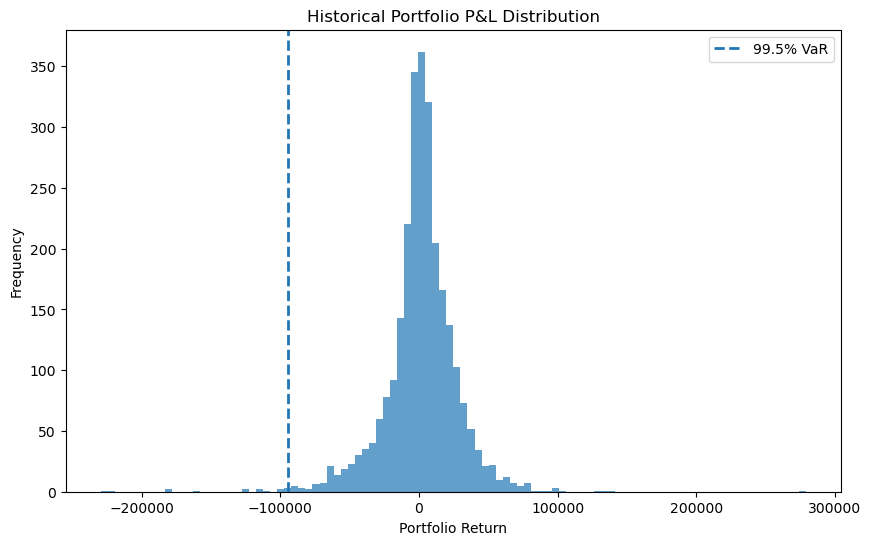

In [65]:
plt.figure(figsize=(10, 6))

plt.hist(pnl, bins=100, alpha=0.7)

plt.axvline(-var_995, linestyle='--', linewidth=2,
            label='99.5% VaR')

plt.title('Historical Portfolio P&L Distribution')
plt.xlabel('Portfolio Return')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [66]:
print("Portfolio_returns:")
print(portfolio_returns.describe())

print("\n99.5% VaR:")
print(var_995)

Portfolio_returns:
count    2707.000000
mean        0.000637
std         0.011496
min        -0.136941
25%        -0.003590
50%         0.000979
75%         0.005925
max         0.108666
dtype: float64

99.5% VaR:
94269.89854281349


In [67]:
print(portfolio_returns.head())

Date
2016-01-05    0.001898
2016-01-06   -0.014162
2016-01-07   -0.028610
2016-01-08   -0.013358
2016-01-11   -0.002088
dtype: float64


### VaR Threshold Line

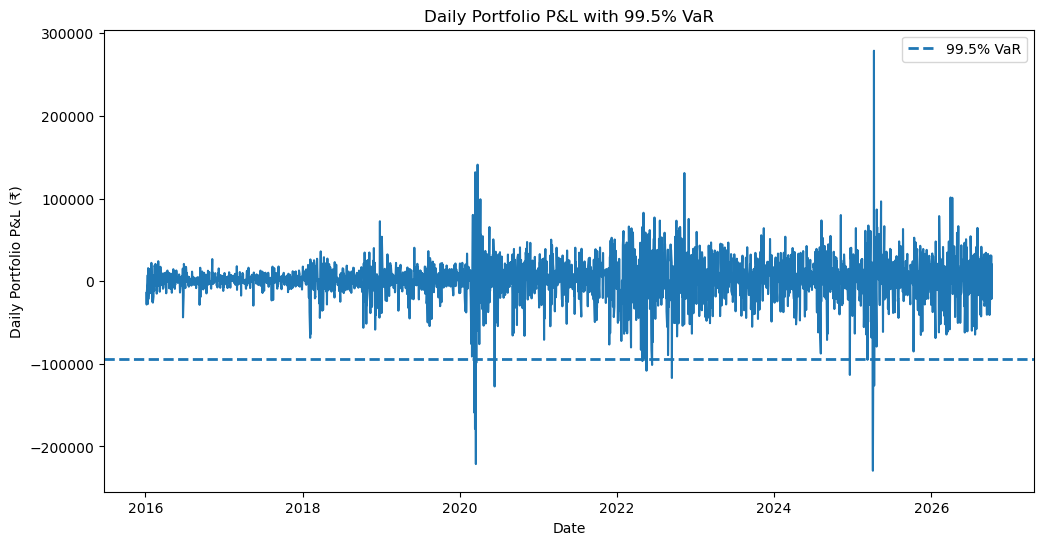

In [68]:
plt.figure(figsize=(12, 6))

plt.plot(pnl.index,pnl)

plt.axhline(-var_995, linestyle='--', linewidth=2,
            label='99.5% VaR')

plt.title('Daily Portfolio P&L with 99.5% VaR')
plt.xlabel('Date')
plt.ylabel('Daily Portfolio P&L (₹)')
plt.legend()

plt.show()

### Rolling VaR

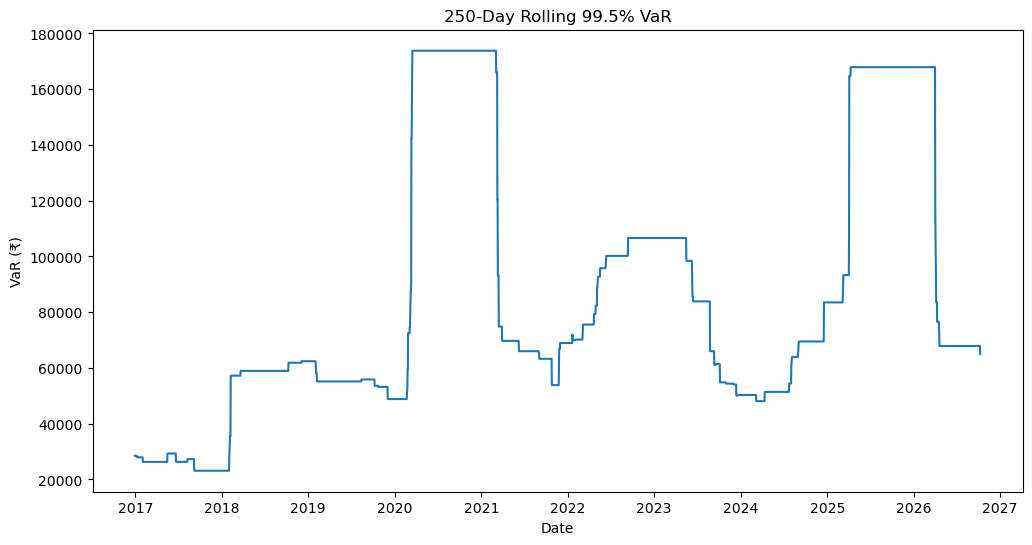

In [69]:
rolling_window = 250

rolling_var_995 = pnl.rolling(rolling_window).quantile(0.005)

plt.figure(figsize=(12, 6))

plt.plot(rolling_var_995.index, -rolling_var_995)

plt.title('250-Day Rolling 99.5% VaR')
plt.xlabel('Date')
plt.ylabel('VaR (₹)')

plt.show()

### Tail Loss Chart

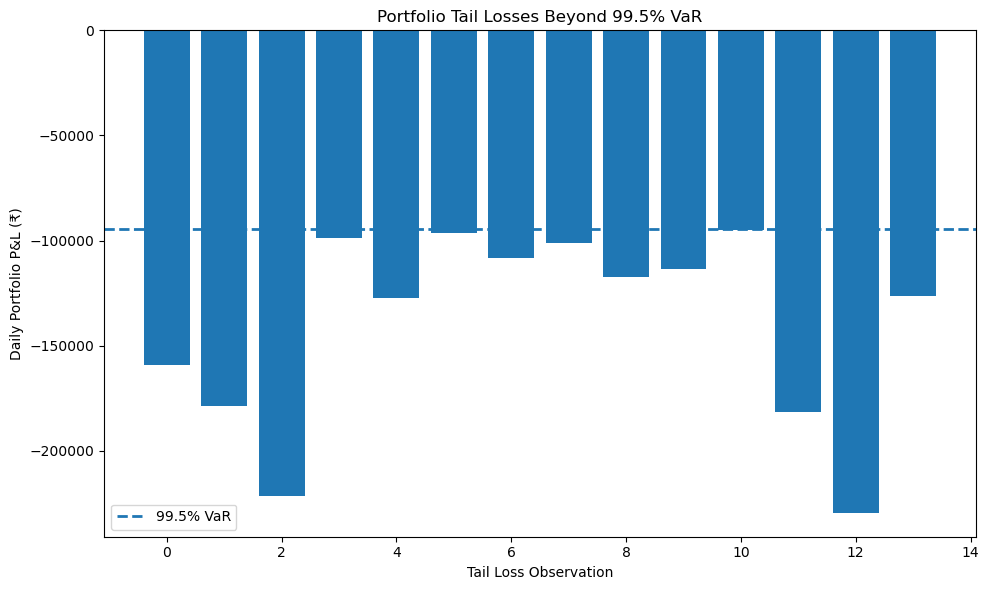

In [70]:
tail_losses = pnl[portfolio_pnl <= -var_995]

plt.figure(figsize=(10, 6))

plt.bar(range(len(tail_losses)), tail_losses)

plt.axhline(-var_995, linestyle='--', linewidth=2,
            label='99.5% VaR')

plt.title('Portfolio Tail Losses Beyond 99.5% VaR')
plt.xlabel('Tail Loss Observation')
plt.ylabel('Daily Portfolio P&L (₹)')
plt.legend()

plt.tight_layout()
plt.show()

### VaR vs Expected Shortfall

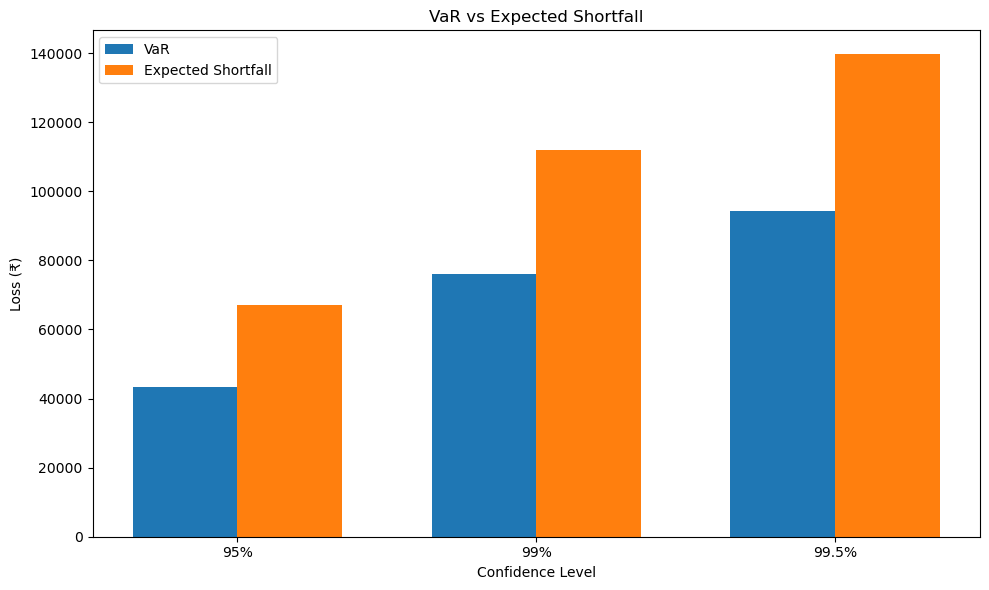

In [71]:
confidence_levels = ['95%', '99%', '99.5%']

VaR_values = [
    var_95,
    var_99,
    var_995 ]

ES_values = [
    es_95,
    es_99,
    es_995
]

x = np.arange(len(confidence_levels))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, VaR_values, width, label='VaR')
plt.bar(x + width/2, ES_values, width, label='Expected Shortfall')

plt.xticks(x, confidence_levels)
plt.xlabel('Confidence Level')
plt.ylabel('Loss (₹)')
plt.title('VaR vs Expected Shortfall')
plt.legend()

plt.tight_layout()
plt.show()

### Phase 5 – EWMA Volatility Scaling

In [72]:
lambda_ = 0.94

ewma_variance = portfolio_returns.pow(2).ewm(alpha=1 - lambda_).mean()

print(ewma_variance.head())

Date
2016-01-05    0.000004
2016-01-06    0.000105
2016-01-07    0.000358
2016-01-08    0.000309
2016-01-11    0.000240
dtype: float64


### Calculate EWMA Volatility

In [73]:
ewma_volatility = np.sqrt(ewma_variance)

print(ewma_volatility.head())

Date
2016-01-05    0.001898
2016-01-06    0.010253
2016-01-07    0.018915
2016-01-08    0.017570
2016-01-11    0.015495
dtype: float64


### Volatility-scaled historical returns

In [74]:
current_volatility = ewma_volatility.iloc[-1]

scaled_returns = portfolio_returns * (current_volatility / ewma_volatility)

print(scaled_returns.tail())

Date
2026-10-05    0.002990
2026-10-06    0.006377
2026-10-07   -0.004455
2026-10-08    0.002872
2026-10-09    0.004300
dtype: float64


### EWMA-scaled Historical VaR

In [75]:
scaled_pnl = scaled_returns * initial_portfolio_value

ewma_var_95 = -np.percentile(scaled_pnl.dropna(), 5)
ewma_var_99 = -np.percentile(scaled_pnl.dropna(), 1)
ewma_var_995 = -np.percentile(scaled_pnl.dropna(), 0.5)

print(f"EWMA-scaled 95% VaR : ₹{ewma_var_95:,.2f}")
print(f"EWMA-scaled 99% VaR : ₹{ewma_var_99:,.2f}")
print(f"EWMA-scaled 99.5% VaR : ₹{ewma_var_995:,.2f}")

EWMA-scaled 95% VaR : ₹8,858.17
EWMA-scaled 99% VaR : ₹13,544.97
EWMA-scaled 99.5% VaR : ₹15,469.05


In [76]:
print("Current EWMA Volatility :", ewma_volatility.iloc[-1])
print("Average EWMA Volatility :", ewma_volatility.mean())
print("Maximum EWMA Volatility :", ewma_volatility.max())

Current EWMA Volatility : 0.005430787163590125
Average EWMA Volatility : 0.009745344677829375
Maximum EWMA Volatility : 0.05789999963344241


### EWMA volatility chart

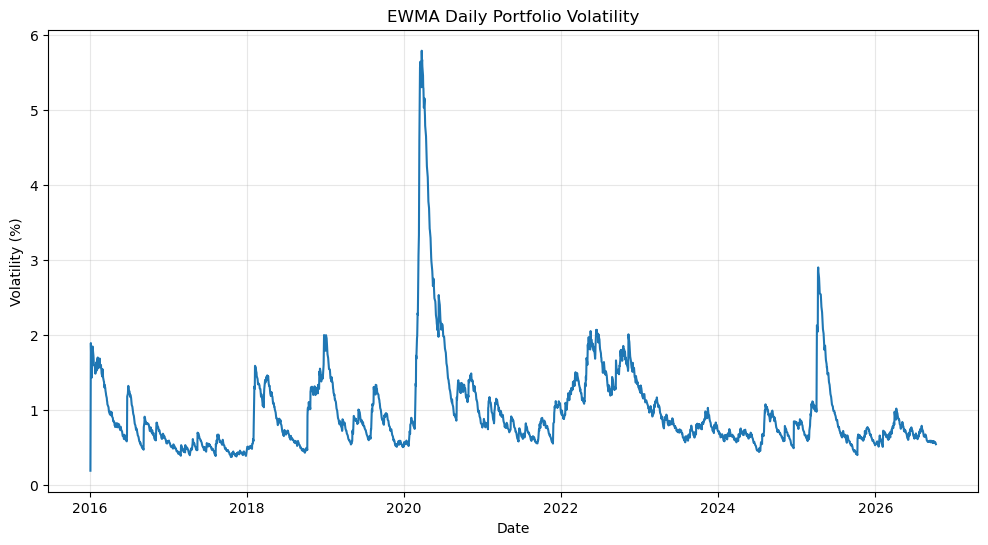

In [77]:
plt.figure(figsize=(12,6))

plt.plot(ewma_volatility.index,
         ewma_volatility*100)

plt.title("EWMA Daily Portfolio Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")

plt.grid(alpha=0.3)

plt.show()

### Raw Returns vs Volatility-Scaled Returns

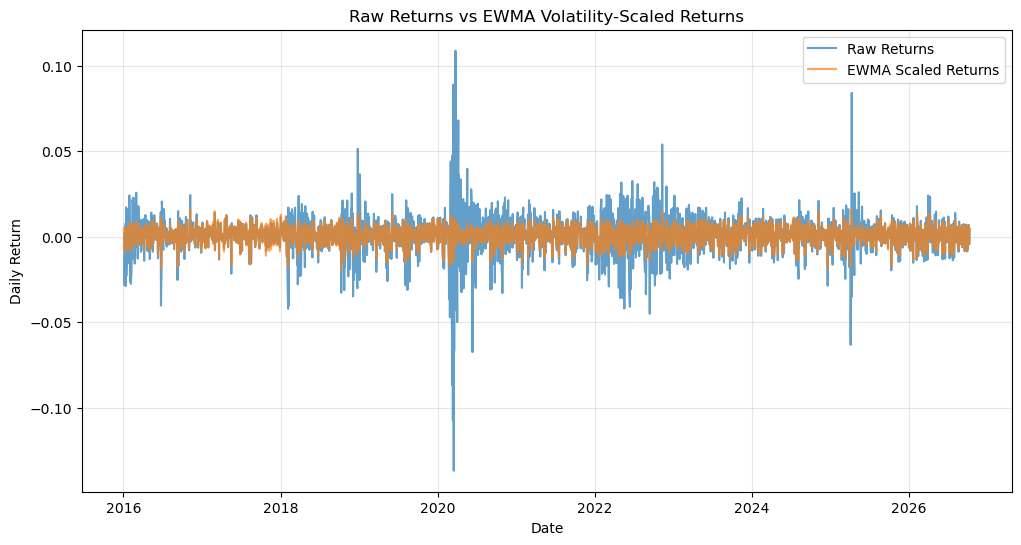

In [78]:
plt.figure(figsize=(12,6))

plt.plot(portfolio_returns.index,
         portfolio_returns,
         label="Raw Returns",
         alpha=0.7)

plt.plot(scaled_returns.index,
         scaled_returns,
         label="EWMA Scaled Returns",
         alpha=0.7)

plt.title("Raw Returns vs EWMA Volatility-Scaled Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Historical VaR vs EWMA-Scaled VaR

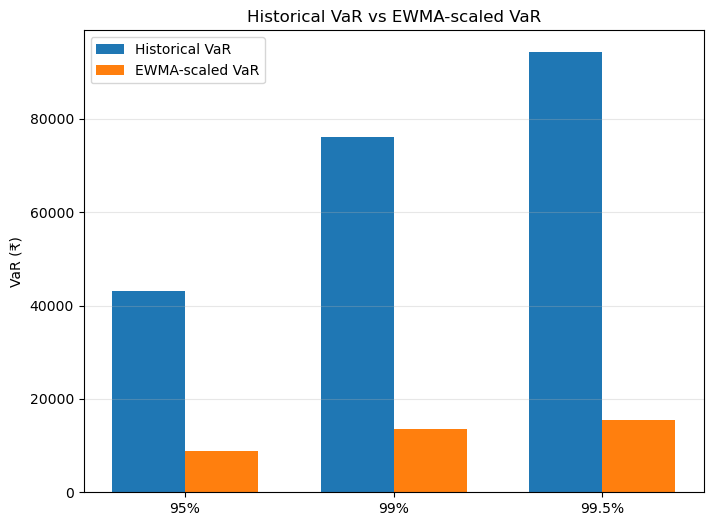

In [79]:
confidence = ["95%", "99%", "99.5%"]
historical_var = [var_95,var_99,var_995]
ewma_var = [ ewma_var_95,ewma_var_99,ewma_var_995]

x = np.arange(len(confidence))
width = 0.35

plt.figure(figsize=(8,6))
plt.bar(x-width/2,
        historical_var,
        width,
        label="Historical VaR")

plt.bar(x+width/2,
        ewma_var,
        width,
        label="EWMA-scaled VaR")

plt.xticks(x, confidence)

plt.title("Historical VaR vs EWMA-scaled VaR")
plt.ylabel("VaR (₹)")
plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.show()

### Exception Comparison Chart

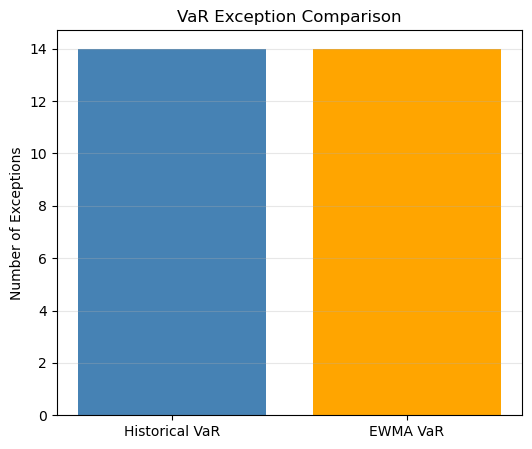

In [80]:
historical_exceptions = (portfolio_pnl < -var_995).sum()

ewma_scaled_pnl = scaled_returns * initial_portfolio_value

ewma_exceptions = (ewma_scaled_pnl < -ewma_var_995).sum()

plt.figure(figsize=(6,5))

plt.bar( ["Historical VaR", "EWMA VaR"], [historical_exceptions, ewma_exceptions], color=["steelblue", "orange"])

plt.title("VaR Exception Comparison")
plt.ylabel("Number of Exceptions")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Phase 6 :GARCH Volatility Scaling

In [81]:
!pip install arch

In [82]:
from arch import arch_model

In [83]:
from arch import arch_model

# Fit GARCH(1,1) model
garch_model = arch_model(portfolio_returns * 100,   # convert returns to %
    vol='GARCH',
    p=1,
    q=1,
    mean='Zero')

garch_fit = garch_model.fit(disp='off')

print(garch_fit.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3507.66
Distribution:                  Normal   AIC:                           7021.32
Method:            Maximum Likelihood   BIC:                           7039.03
                                        No. Observations:                 2707
Date:                Fri, Oct 09 2026   Df Residuals:                     2707
Time:                        21:29:43   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0361  9.471e-03      3.817  1.352e-04 [1.

### Conditional Volatility

In [84]:
garch_volatility = garch_fit.conditional_volatility / 100

print(garch_volatility.head())

Date
2016-01-05    0.015387
2016-01-06    0.014067
2016-01-07    0.013972
2016-01-08    0.016868
2016-01-11    0.016213
Name: cond_vol, dtype: float64


### GARCH forecast volatility

In [85]:
forecast = garch_fit.forecast(horizon=1)

forecast_variance = forecast.variance.iloc[-1, 0]

forecast_volatility = np.sqrt(forecast_variance) / 100

print(f"1-Day Ahead GARCH Volatility: {forecast_volatility:.6f}")
print(f"1-Day Ahead GARCH Volatility: {forecast_volatility:.4%}")

1-Day Ahead GARCH Volatility: 0.006304
1-Day Ahead GARCH Volatility: 0.6304%


### Historical VaR vs GARCH-scaled VaR

In [86]:
garch_scaled_returns = portfolio_returns * (forecast_volatility / garch_volatility)

print(garch_scaled_returns.head())

Date
2016-01-05    0.000777
2016-01-06   -0.006347
2016-01-07   -0.012910
2016-01-08   -0.004992
2016-01-11   -0.000812
dtype: float64


In [87]:
# Calculate GARCH-scaled Historical VaR

In [88]:
initial_portfolio_value = 1000000

In [89]:
garch_scaled_pnl = (garch_scaled_returns * initial_portfolio_value)
garch_scaled_pnl

Date
2016-01-05      777.461224
2016-01-06    -6346.965468
2016-01-07   -12909.514506
2016-01-08    -4992.411812
2016-01-11     -811.730418
                  ...     
2026-10-05     2856.121488
2026-10-06     6406.005654
2026-10-07    -4312.226478
2026-10-08     2764.340035
2026-10-09     4243.763949
Length: 2707, dtype: float64

In [90]:
garch_var_95 = -np.percentile(garch_scaled_pnl.dropna(), 5)

garch_var_99 = -np.percentile(garch_scaled_pnl.dropna(), 1)

garch_var_995 = -np.percentile(garch_scaled_pnl.dropna(), 0.5)

print(f"GARCH-scaled 95% VaR   : ₹{garch_var_95:,.2f}")
print(f"GARCH-scaled 99% VaR   : ₹{garch_var_99:,.2f}")
print(f"GARCH-scaled 99.5% VaR : ₹{garch_var_995:,.2f}")

GARCH-scaled 95% VaR   : ₹10,695.31
GARCH-scaled 99% VaR   : ₹17,370.16
GARCH-scaled 99.5% VaR : ₹21,378.70


#### Chart 1 — GARCH Conditional Volatility

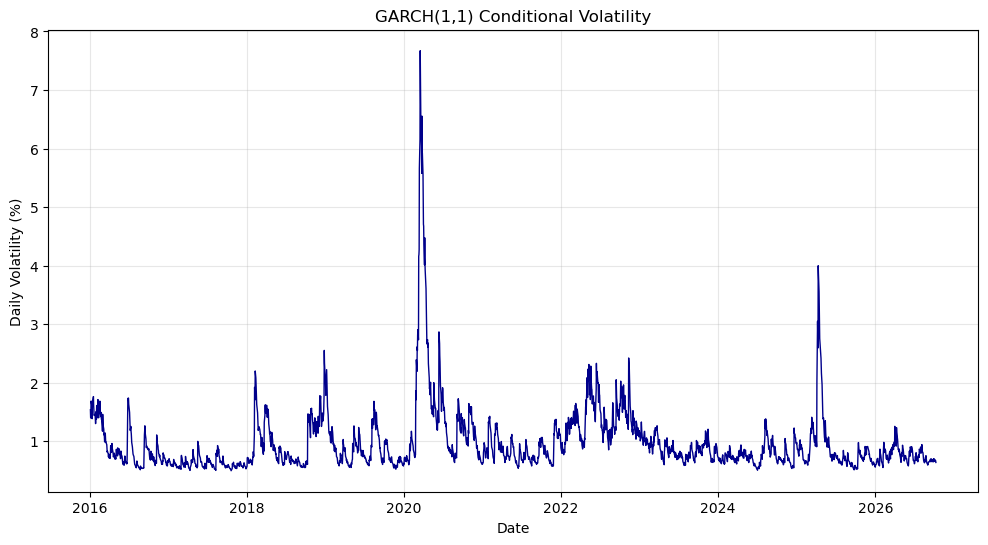

In [91]:
plt.figure(figsize=(12, 6))

plt.plot(garch_volatility.index,
    garch_volatility * 100,
    color='darkblue',
    linewidth=1)

plt.title('GARCH(1,1) Conditional Volatility')
plt.xlabel('Date')
plt.ylabel('Daily Volatility (%)')
plt.grid(alpha=0.3)

plt.show()

In [92]:
# Generate rolling 1-day-ahead forecasts

In [93]:
garch_forecast = garch_fit.forecast(horizon=1,reindex=True)

garch_forecast_variance = garch_forecast.variance.iloc[:, 0]

garch_forecast_volatility = np.sqrt(garch_forecast_variance) / 100

print(garch_forecast_volatility.dropna().head())

Date
2026-10-09    0.006304
Name: h.1, dtype: float64


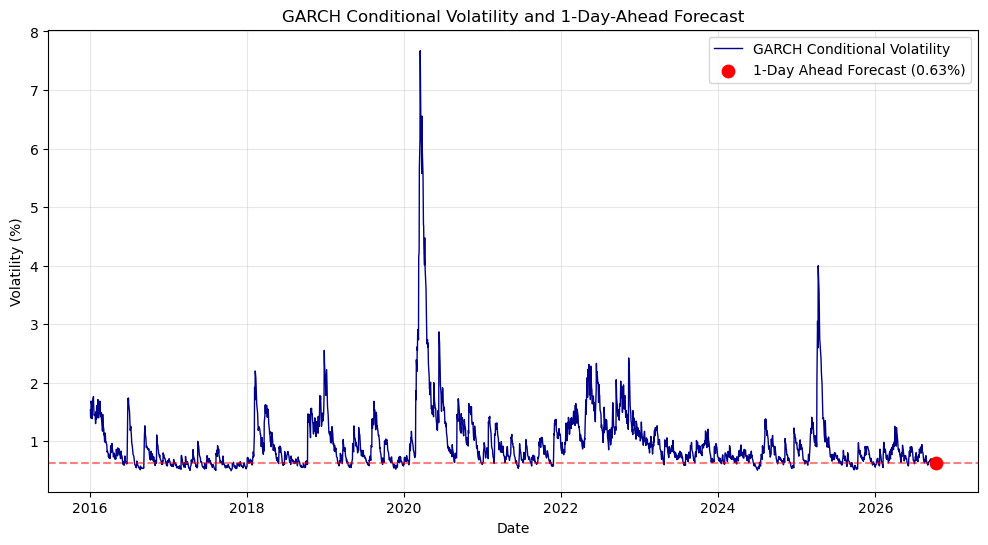

In [94]:
plt.figure(figsize=(12, 6))

plt.plot(garch_volatility.index,
    garch_volatility * 100,
    label='GARCH Conditional Volatility',
    color='darkblue',
    linewidth=1)

forecast_date = garch_forecast_volatility.dropna().index[-1]
forecast_value = garch_forecast_volatility.dropna().iloc[-1] * 100

plt.scatter(forecast_date,forecast_value,
    color='red',
    s=80,
    zorder=5,
    label=f'1-Day Ahead Forecast ({forecast_value:.2f}%)')

plt.axhline(forecast_value,
    color='red',
    linestyle='--',
    alpha=0.5)

plt.title('GARCH Conditional Volatility and 1-Day-Ahead Forecast')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Chart 3 — Historical VaR vs GARCH-Scaled VaR

In [95]:
print(f"Historical 95% VaR   : ₹{var_95:,.2f}")
print(f"Historical 99% VaR   : ₹{var_99:,.2f}")
print(f"Historical 99.5% VaR : ₹{var_995:,.2f}")

Historical 95% VaR   : ₹43,227.76
Historical 99% VaR   : ₹76,020.48
Historical 99.5% VaR : ₹94,269.90


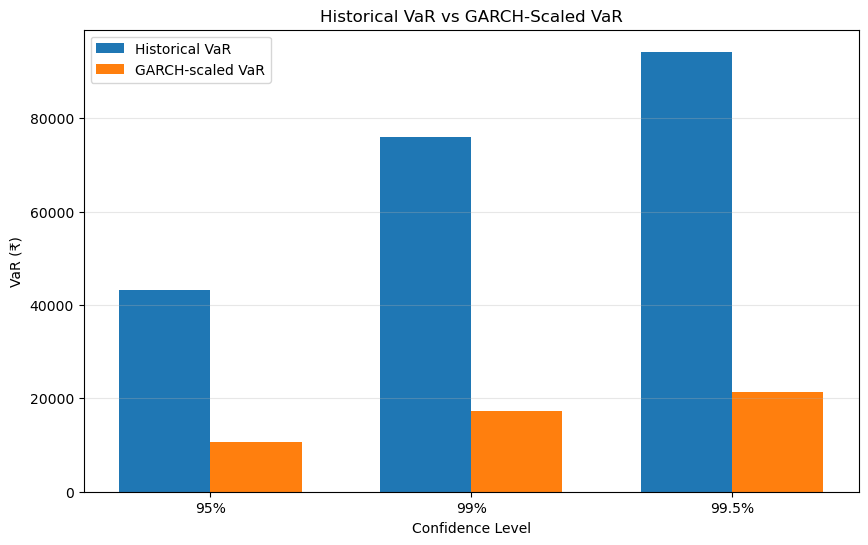

In [96]:
confidence_levels = ['95%', '99%', '99.5%']

historical_var = [var_95,var_99,var_995]

garch_var = [garch_var_95,garch_var_99,garch_var_995]

x = np.arange(len(confidence_levels))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2,historical_var,width,label='Historical VaR')

plt.bar(x + width/2,garch_var,width,label='GARCH-scaled VaR')

plt.xticks(x, confidence_levels)
plt.ylabel('VaR (₹)')
plt.xlabel('Confidence Level')
plt.title('Historical VaR vs GARCH-Scaled VaR')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

### Chart 4 — GARCH Standardized Residuals

In [97]:
standardized_residuals = garch_fit.std_resid

print(standardized_residuals.head())

Date
2016-01-05    0.123322
2016-01-06   -1.006761
2016-01-07   -2.047719
2016-01-08   -0.791901
2016-01-11   -0.128757
Name: std_resid, dtype: float64


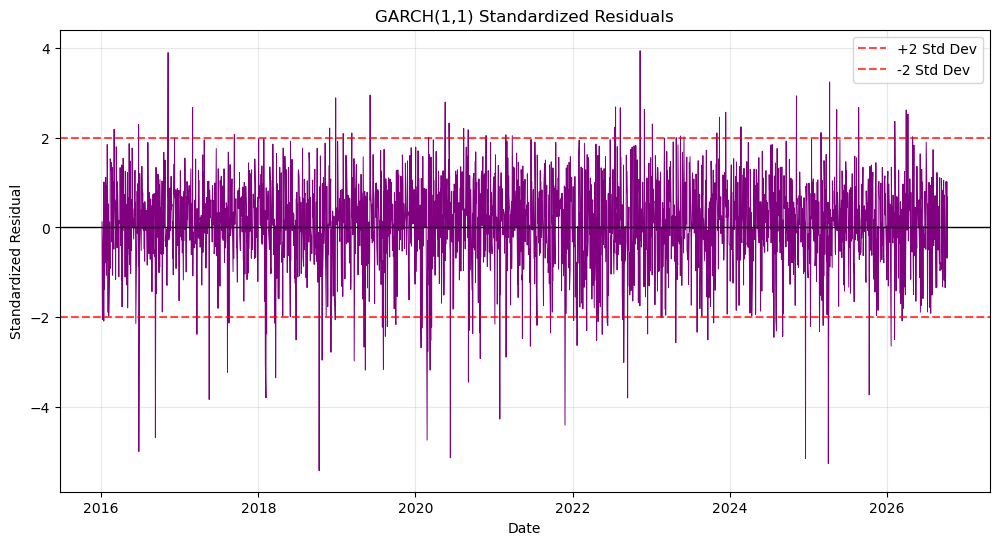

In [98]:
plt.figure(figsize=(12, 6))

plt.plot(standardized_residuals.index,standardized_residuals,color='purple',
    linewidth=0.7)

plt.axhline(0, color='black', linewidth=1)

plt.axhline(2,color='red',linestyle='--',alpha=0.7,
    label='+2 Std Dev')

plt.axhline(-2,color='red',linestyle='--',alpha=0.7,
    label='-2 Std Dev')

plt.title('GARCH(1,1) Standardized Residuals')
plt.xlabel('Date')
plt.ylabel('Standardized Residual')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
garch_volatility = garch_fit.conditional_volatility

garch_volatility.head()

Date
2016-01-05    1.538677
2016-01-06    1.406661
2016-01-07    1.397187
2016-01-08    1.686819
2016-01-11    1.621272
Name: cond_vol, dtype: float64

### Plot the volatility clustering

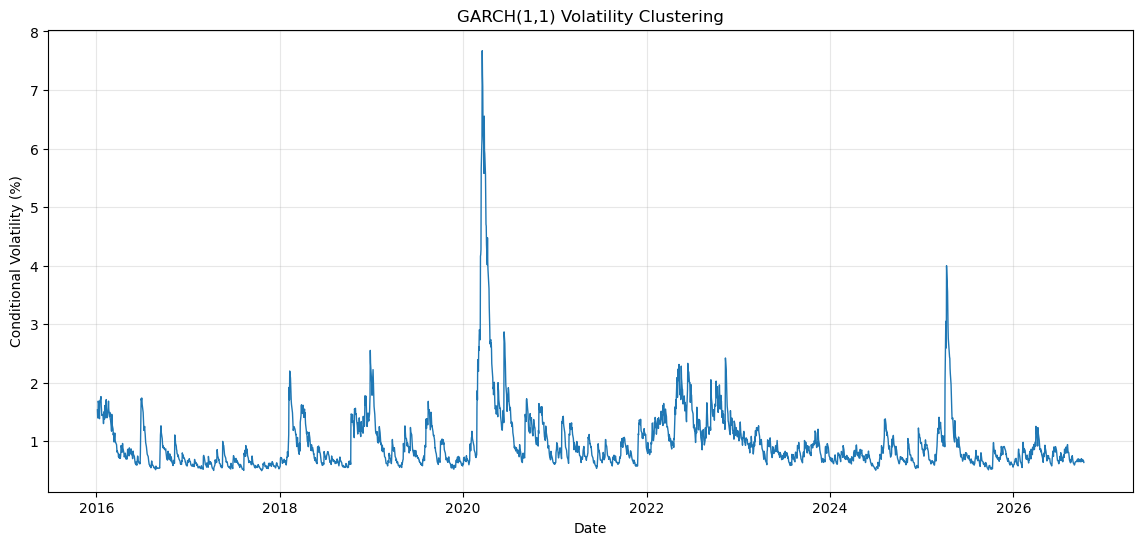

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    garch_volatility.index,
    garch_volatility,
    linewidth=1
)

plt.title('GARCH(1,1) Volatility Clustering')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility (%)')
plt.grid(alpha=0.3)

plt.show()

### Phase 7 – GJR-GARCH Volatility Scaling

In [102]:
print(garch_forecast_volatility.dropna().head())

Date
2026-10-09    0.006304
Name: h.1, dtype: float64


In [103]:
garch_fit.conditional_volatility

Date
2016-01-05    1.538677
2016-01-06    1.406661
2016-01-07    1.397187
2016-01-08    1.686819
2016-01-11    1.621272
                ...   
2026-10-05    0.681699
2026-10-06    0.656140
2026-10-07    0.673966
2026-10-08    0.662785
2026-10-09    0.638823
Name: cond_vol, Length: 2707, dtype: float64

In [104]:
# Convert GARCH conditional volatility from % to decimal
garch_cond_vol = garch_fit.conditional_volatility / 100

print(garch_cond_vol.head())

Date
2016-01-05    0.015387
2016-01-06    0.014067
2016-01-07    0.013972
2016-01-08    0.016868
2016-01-11    0.016213
Name: cond_vol, dtype: float64


In [105]:
from arch import arch_model

# Remove missing values
gjr_returns = portfolio_returns.dropna()

# Convert to percentage
gjr_returns_pct = gjr_returns * 100

# Fit GJR-GARCH(1,1)
gjr_model = arch_model(
    gjr_returns_pct,
    mean='Constant',
    vol='GARCH',
    p=1,
    o=1,
    q=1,
    dist='normal'
)

gjr_fit = gjr_model.fit(disp='off')

print(gjr_fit.summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -3458.06
Distribution:                  Normal   AIC:                           6926.13
Method:            Maximum Likelihood   BIC:                           6955.65
                                        No. Observations:                 2707
Date:                Fri, Oct 09 2026   Df Residuals:                     2706
Time:                        21:30:52   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0624  1.444e-02      4.319  1.569e-05 [3.

In [106]:
gjr_cond_vol = gjr_fit.conditional_volatility / 100

print(gjr_cond_vol.tail())

Date
2026-10-05    0.007385
2026-10-06    0.007008
2026-10-07    0.006787
2026-10-08    0.006903
2026-10-09    0.006582
Name: cond_vol, dtype: float64


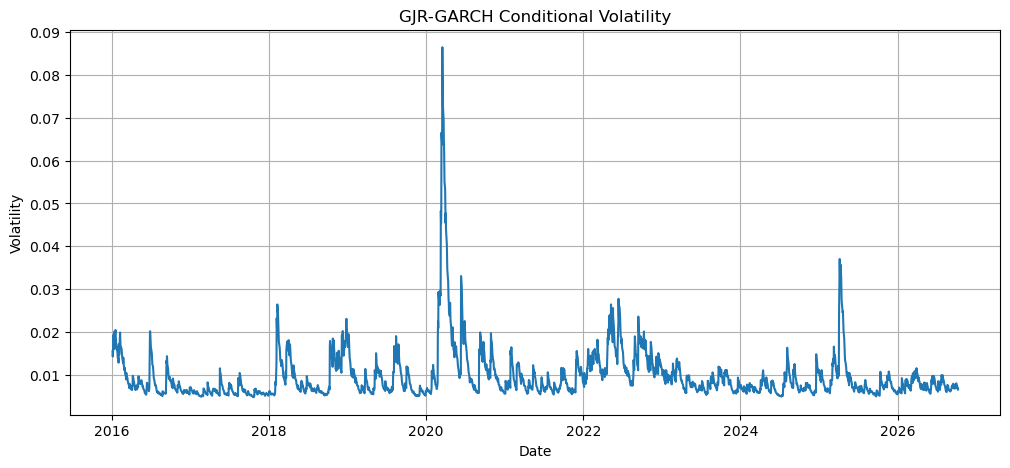

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(gjr_cond_vol)

plt.title("GJR-GARCH Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(True)
plt.show()

In [108]:
# Current 1-day-ahead GARCH volatility forecast
current_volatility = garch_forecast_volatility.dropna().iloc[-1]

print("Current GARCH forecast volatility:", current_volatility)

Current GARCH forecast volatility: 0.006304340359214328


In [109]:
# Align returns with GARCH conditional volatility
common_index = portfolio_returns.index.intersection(garch_cond_vol.index)

aligned_returns = portfolio_returns.loc[common_index]
aligned_volatility = garch_cond_vol.loc[common_index]

# GARCH-scaled historical returns
garch_scaled_returns = (
    aligned_returns * (current_volatility / aligned_volatility)
)

print(garch_scaled_returns.head())

Date
2016-01-05    0.000777
2016-01-06   -0.006347
2016-01-07   -0.012910
2016-01-08   -0.004992
2016-01-11   -0.000812
dtype: float64


### Forecast next-day GJR-GARCH volatility

In [110]:
gjr_forecast = gjr_fit.forecast(horizon=1)

gjr_forecast_variance = gjr_forecast.variance.iloc[-1, 0]

gjr_forecast_volatility = (
    gjr_forecast_variance ** 0.5
) / 100

print(
    "GJR-GARCH 1-day-ahead volatility:",
    gjr_forecast_volatility
)

GJR-GARCH 1-day-ahead volatility: 0.006334003636753471


### Align returns and volatility

In [111]:
common_index_gjr = (portfolio_returns.index
    .intersection(gjr_cond_vol.index))

aligned_returns_gjr = (portfolio_returns.loc[common_index_gjr])

aligned_volatility_gjr = (gjr_cond_vol.loc[common_index_gjr])

### Calculate GJR-GARCH-scaled historical returns

In [112]:
gjr_scaled_returns = (aligned_returns_gjr *(gjr_forecast_volatility / aligned_volatility_gjr))

print(gjr_scaled_returns.tail())

Date
2026-10-05    0.002649
2026-10-06    0.006026
2026-10-07   -0.004303
2026-10-08    0.002667
2026-10-09    0.004138
dtype: float64


### Calculate GJR-GARCH-scaled VaR

In [113]:
# Calculate GARCH-scaled Historical VaR

gjr_var_95 = -gjr_scaled_returns.quantile(0.05)
gjr_var_99 = -gjr_scaled_returns.quantile(0.01)
gjr_var_995 = -gjr_scaled_returns.quantile(0.005)

print("GJR-GARCH-scaled VaR (95%):", gjr_var_95)
print("GJR-GARCH-scaled VaR (99%):", gjr_var_99)
print("GJR-GARCH-scaled VaR (99.5%):", gjr_var_995)

GJR-GARCH-scaled VaR (95%): 0.010714426859051907
GJR-GARCH-scaled VaR (99%): 0.016720169506877543
GJR-GARCH-scaled VaR (99.5%): 0.02171194229415247


### Volatility comparison

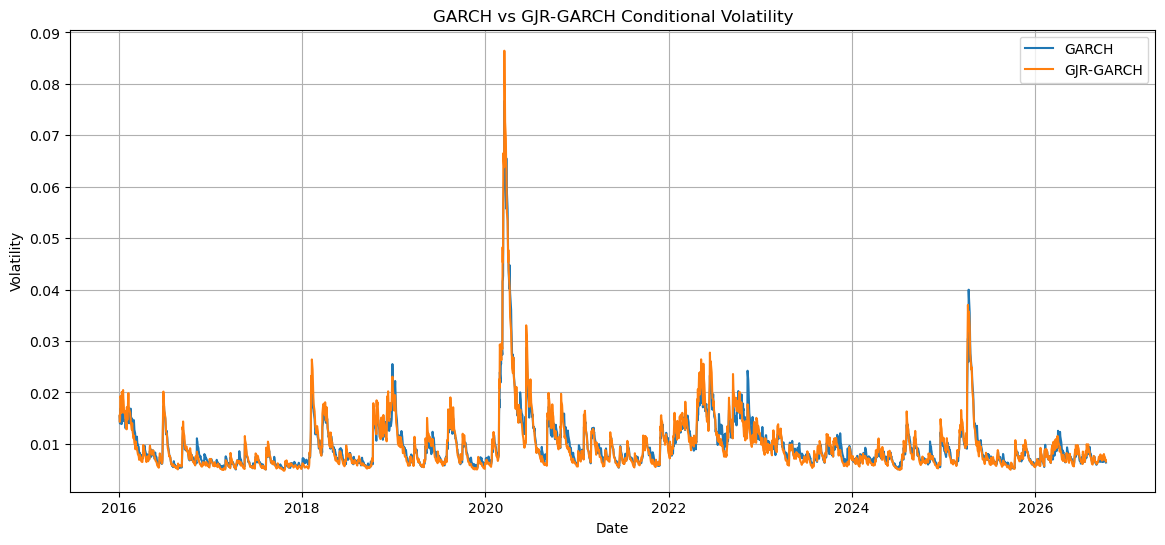

In [114]:
plt.figure(figsize=(14,6))

plt.plot(garch_cond_vol, label='GARCH')
plt.plot(gjr_cond_vol, label='GJR-GARCH')

plt.title("GARCH vs GJR-GARCH Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)

plt.show()

In [115]:
print(gjr_fit.summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -3458.06
Distribution:                  Normal   AIC:                           6926.13
Method:            Maximum Likelihood   BIC:                           6955.65
                                        No. Observations:                 2707
Date:                Fri, Oct 09 2026   Df Residuals:                     2706
Time:                        21:30:52   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0624  1.444e-02      4.319  1.569e-05 [3.

In [116]:
# GJR-GARCH conditional volatility
gjr_cond_vol = gjr_fit.conditional_volatility / 100

print(gjr_cond_vol.tail())

Date
2026-10-05    0.007385
2026-10-06    0.007008
2026-10-07    0.006787
2026-10-08    0.006903
2026-10-09    0.006582
Name: cond_vol, dtype: float64


### Plot GJR-GARCH Volatility

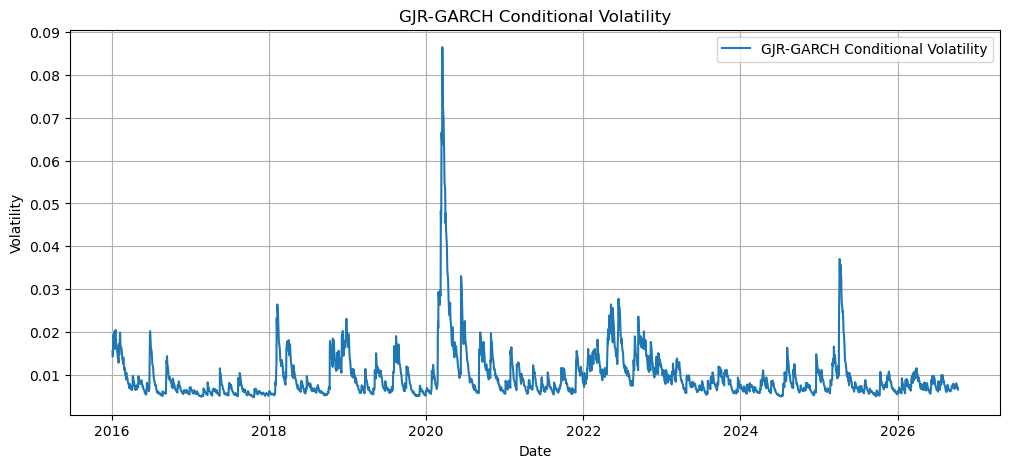

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    gjr_cond_vol,
    label='GJR-GARCH Conditional Volatility'
)

plt.title('GJR-GARCH Conditional Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)

plt.show()

### GARCH vs GJR-GARCH Volatility Comparison

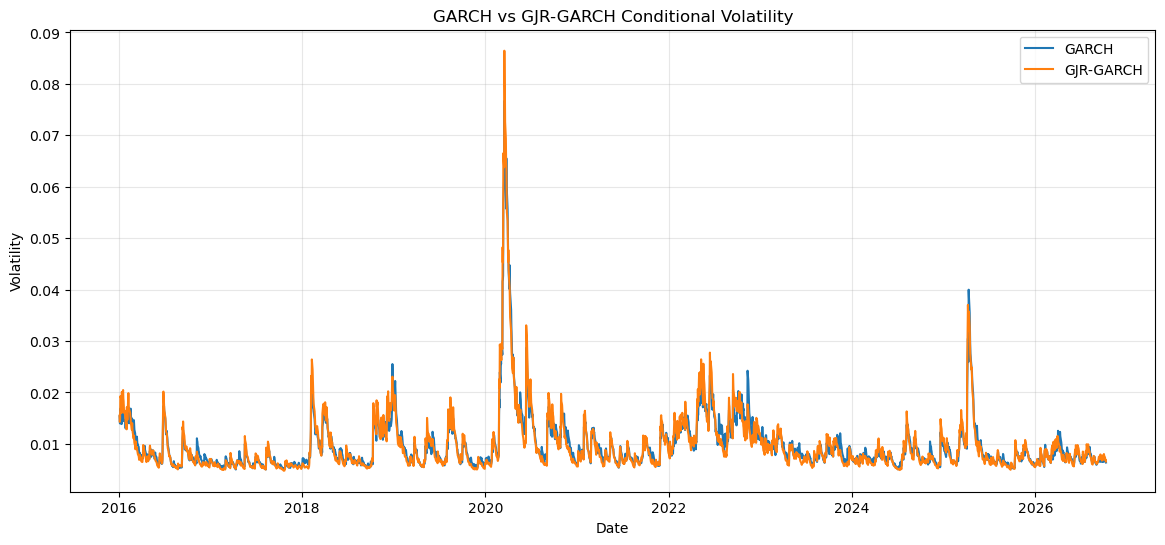

In [118]:
plt.figure(figsize=(14, 6))

plt.plot(
    garch_cond_vol.index,
    garch_cond_vol,
    label='GARCH'
)

plt.plot(
    gjr_cond_vol.index,
    gjr_cond_vol,
    label='GJR-GARCH'
)

plt.title('GARCH vs GJR-GARCH Conditional Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Leverage effect visualization

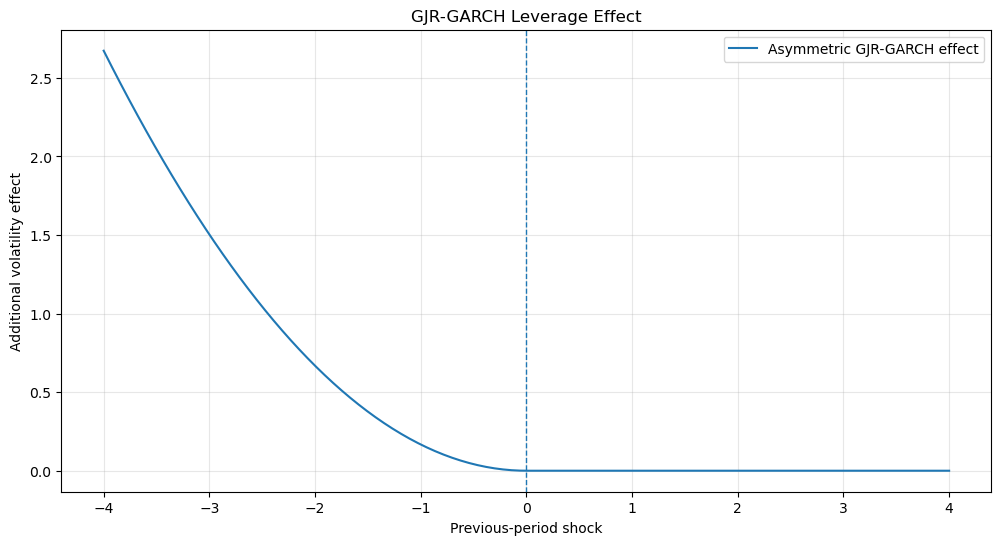

In [119]:
import numpy as np

# Range of standardized shocks
shocks = np.linspace(-4, 4, 200)

gamma = gjr_fit.params['gamma[1]']

# Additional asymmetric effect
leverage_effect = gamma * (shocks ** 2) * (shocks < 0)

plt.figure(figsize=(12, 6))

plt.plot(
    shocks,
    leverage_effect,
    label='Asymmetric GJR-GARCH effect'
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=1
)

plt.title('GJR-GARCH Leverage Effect')
plt.xlabel('Previous-period shock')
plt.ylabel('Additional volatility effect')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Historical VaR vs GJR-GARCH-scaled VaR

In [120]:
confidence_levels = ['95%', '99%', '99.5%']

historical_vars = [
    var_95,
    var_99,
    var_995
]

gjr_vars = [
    gjr_var_95,
    gjr_var_99,
    gjr_var_995
]

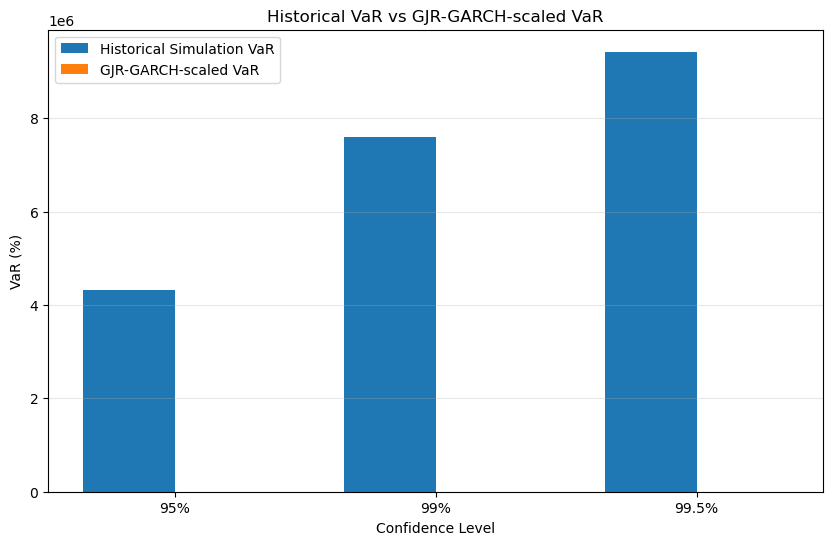

In [121]:
plt.figure(figsize=(10, 6))

x = np.arange(len(confidence_levels))
width = 0.35

plt.bar(
    x - width/2,
    np.array(historical_vars) * 100,
    width,
    label='Historical Simulation VaR'
)

plt.bar(
    x + width/2,
    np.array(gjr_vars) * 100,
    width,
    label='GJR-GARCH-scaled VaR'
)

plt.xticks(x, confidence_levels)

plt.xlabel('Confidence Level')
plt.ylabel('VaR (%)')
plt.title('Historical VaR vs GJR-GARCH-scaled VaR')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()


### Phase 8: VaR Backtesting

In [122]:
portfolio_returns

Date
2016-01-05    0.001898
2016-01-06   -0.014162
2016-01-07   -0.028610
2016-01-08   -0.013358
2016-01-11   -0.002088
                ...   
2026-10-05    0.003088
2026-10-06    0.006667
2026-10-07   -0.004610
2026-10-08    0.002906
2026-10-09    0.004300
Length: 2707, dtype: float64

In [123]:
portfolio_returns.head()

Date
2016-01-05    0.001898
2016-01-06   -0.014162
2016-01-07   -0.028610
2016-01-08   -0.013358
2016-01-11   -0.002088
dtype: float64

In [124]:
portfolio_returns = portfolio_returns.dropna()
portfolio_returns

Date
2016-01-05    0.001898
2016-01-06   -0.014162
2016-01-07   -0.028610
2016-01-08   -0.013358
2016-01-11   -0.002088
                ...   
2026-10-05    0.003088
2026-10-06    0.006667
2026-10-07   -0.004610
2026-10-08    0.002906
2026-10-09    0.004300
Length: 2707, dtype: float64

### Now create a rolling 750-day Historical VaR

In [125]:
import numpy as np
import pandas as pd

confidence_level = 0.95
window = 750

historical_var = []

for i in range(window, len(portfolio_returns)):

    # Previous 750 returns
    historical_returns = portfolio_returns.iloc[i-window:i]

    # 5% worst percentile
    var_return = np.percentile(
        historical_returns,
        (1 - confidence_level) * 100
    )

    # Convert negative return VaR into positive loss
    var_loss = -var_return

    historical_var.append(var_loss)

In [126]:
backtest_dates = portfolio_returns.index[window:]

In [127]:
backtest_df = pd.DataFrame({
    'Actual_Return': portfolio_returns.iloc[window:].values,
    'VaR': historical_var
}, index=backtest_dates)

In [128]:
backtest_df.head()

,Actual_Return,VaR
Date,,
2018-12-27,0.008214,0.015377
2018-12-28,0.001394,0.015377
2018-12-31,0.009255,0.015377
2019-01-02,0.000131,0.015164
2019-01-03,-0.025405,0.015164


In [129]:
backtest_df['Actual_Loss'] = -backtest_df['Actual_Return']

In [130]:
backtest_df['Exception'] = (
    backtest_df['Actual_Loss'] > backtest_df['VaR'])

In [131]:
backtest_df.head(10)

,Actual_Return,VaR,Actual_Loss,Exception
Date,,,,
2018-12-27,0.008214,0.015377,-0.008214,False
2018-12-28,0.001394,0.015377,-0.001394,False
2018-12-31,0.009255,0.015377,-0.009255,False
2019-01-02,0.000131,0.015164,-0.000131,False
2019-01-03,-0.025405,0.015164,0.025405,True
2019-01-04,0.036417,0.015377,-0.036417,False
2019-01-07,0.010850,0.015377,-0.010850,False
2019-01-08,0.007323,0.015164,-0.007323,False
2019-01-09,0.002784,0.015164,-0.002784,False


In [132]:
number_of_exceptions = backtest_df['Exception'].sum()

total_backtest_days = len(backtest_df)

exception_ratio = (
    number_of_exceptions / total_backtest_days
)

expected_exception_ratio = 1 - confidence_level

expected_exceptions = (
    total_backtest_days * expected_exception_ratio
)

In [133]:
print("Total Backtesting Days:", total_backtest_days)
print("Number of Exceptions:", number_of_exceptions)
print("Exception Ratio:", exception_ratio)
print("Expected Exception Ratio:", expected_exception_ratio)
print("Expected Exceptions:", expected_exceptions)

Total Backtesting Days: 1957
Number of Exceptions: 86
Exception Ratio: 0.04394481349003577
Expected Exception Ratio: 0.050000000000000044
Expected Exceptions: 97.8500000000001


### Plot Actual Loss vs VaR

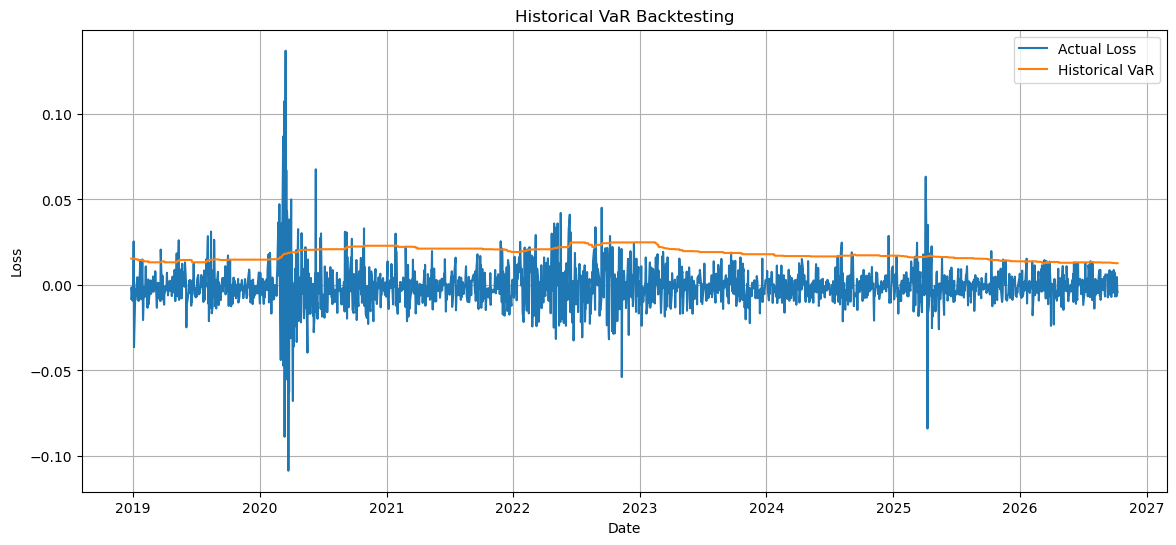

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    backtest_df.index,
    backtest_df['Actual_Loss'],
    label='Actual Loss'
)

plt.plot(
    backtest_df.index,
    backtest_df['VaR'],
    label='Historical VaR'
)

plt.title('Historical VaR Backtesting')
plt.xlabel('Date')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

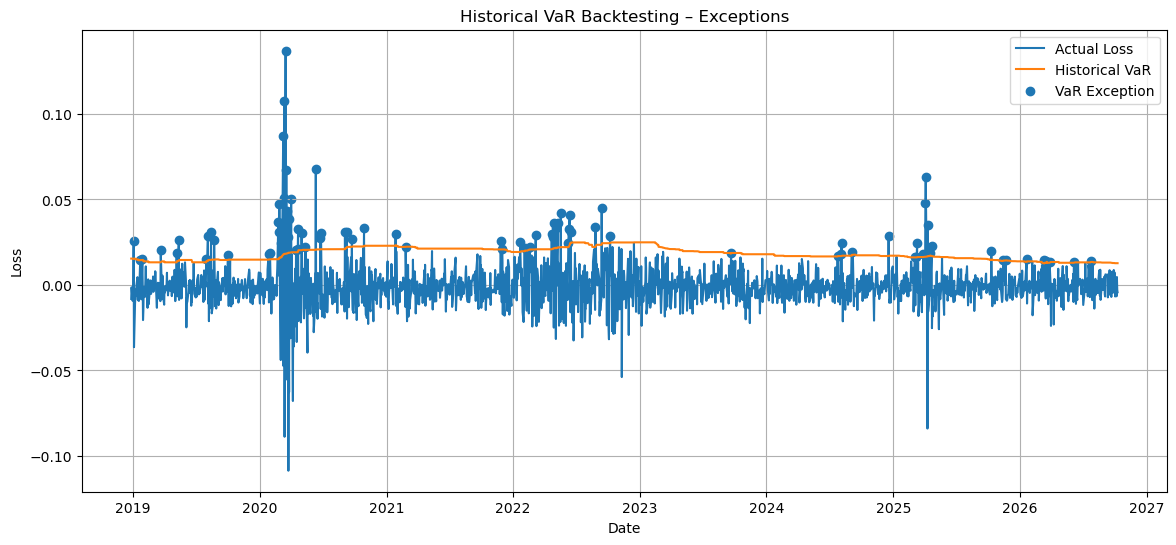

In [135]:
plt.figure(figsize=(14, 6))

plt.plot(
    backtest_df.index,
    backtest_df['Actual_Loss'],
    label='Actual Loss'
)

plt.plot(
    backtest_df.index,
    backtest_df['VaR'],
    label='Historical VaR'
)

exceptions = backtest_df[backtest_df['Exception']]

plt.scatter(
    exceptions.index,
    exceptions['Actual_Loss'],
    label='VaR Exception'
)

plt.title('Historical VaR Backtesting – Exceptions')
plt.xlabel('Date')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [136]:
print("Total Backtesting Days:", total_backtest_days)
print("Number of Exceptions:", number_of_exceptions)
print("Exception Ratio:", exception_ratio)
print("Expected Exception Ratio:", expected_exception_ratio)
print("Expected Exceptions:", expected_exceptions)

Total Backtesting Days: 1957
Number of Exceptions: 86
Exception Ratio: 0.04394481349003577
Expected Exception Ratio: 0.050000000000000044
Expected Exceptions: 97.8500000000001


In [137]:
backtest_df.head()

,Actual_Return,VaR,Actual_Loss,Exception
Date,,,,
2018-12-27,0.008214,0.015377,-0.008214,False
2018-12-28,0.001394,0.015377,-0.001394,False
2018-12-31,0.009255,0.015377,-0.009255,False
2019-01-02,0.000131,0.015164,-0.000131,False
2019-01-03,-0.025405,0.015164,0.025405,True


In [138]:
print("Total Backtesting Days:", total_backtest_days)
print("Number of Exceptions:", number_of_exceptions)
print("Exception Ratio:", exception_ratio)
print("Expected Exception Ratio:", expected_exception_ratio)
print("Expected Exceptions:", expected_exceptions)

Total Backtesting Days: 1957
Number of Exceptions: 86
Exception Ratio: 0.04394481349003577
Expected Exception Ratio: 0.050000000000000044
Expected Exceptions: 97.8500000000001


In [139]:
backtest_df.head()

,Actual_Return,VaR,Actual_Loss,Exception
Date,,,,
2018-12-27,0.008214,0.015377,-0.008214,False
2018-12-28,0.001394,0.015377,-0.001394,False
2018-12-31,0.009255,0.015377,-0.009255,False
2019-01-02,0.000131,0.015164,-0.000131,False
2019-01-03,-0.025405,0.015164,0.025405,True


In [140]:
print("Total Backtesting Days:", total_backtest_days)
print("Number of Exceptions:", number_of_exceptions)
print("Exception Ratio:", exception_ratio)
print("Expected Exception Ratio:", expected_exception_ratio)
print("Expected Exceptions:", expected_exceptions)

Total Backtesting Days: 1957
Number of Exceptions: 86
Exception Ratio: 0.04394481349003577
Expected Exception Ratio: 0.050000000000000044
Expected Exceptions: 97.8500000000001


In [141]:
backtest_df['Exception'].value_counts()

Exception
False    1871
True       86
Name: count, dtype: int64

### Kupiec POF Test

In [142]:
from scipy.stats import chi2
import numpy as np

# Total observations
T = len(backtest_df)

# Number of exceptions
x = backtest_df['Exception'].sum()

# Expected exception probability for 95% VaR
p = 1 - confidence_level

# Observed exception probability
phat = x / T

# Kupiec Likelihood Ratio
LR_POF = -2 * np.log(
    ((1 - p)**(T - x) * p**x) /
    ((1 - phat)**(T - x) * phat**x)
)

# P-value
p_value = chi2.sf(LR_POF, df=1)

print("----- Kupiec POF Test -----")
print("Total observations:", T)
print("Exceptions:", x)
print("Expected exception probability:", p)
print("Observed exception probability:", phat)
print("LR POF statistic:", LR_POF)
print("P-value:", p_value)

----- Kupiec POF Test -----
Total observations: 1957
Exceptions: 86
Expected exception probability: 0.050000000000000044
Observed exception probability: 0.04394481349003577
LR POF statistic: 1.572166134504901
P-value: 0.20989271714610708


### exception transition table

In [143]:
# Convert exceptions to integers
exceptions = backtest_df['Exception'].astype(int)

# Previous day's exception
prev_exception = exceptions.shift(1)

# Remove first observation
transition_df = pd.DataFrame({
    'Previous': prev_exception,
    'Current': exceptions
}).dropna()

# Transition counts
n00 = ((transition_df['Previous'] == 0) &
       (transition_df['Current'] == 0)).sum()

n01 = ((transition_df['Previous'] == 0) &
       (transition_df['Current'] == 1)).sum()

n10 = ((transition_df['Previous'] == 1) &
       (transition_df['Current'] == 0)).sum()

n11 = ((transition_df['Previous'] == 1) &
       (transition_df['Current'] == 1)).sum()

print("----- Transition Counts -----")
print("n00:", n00)
print("n01:", n01)
print("n10:", n10)
print("n11:", n11)

----- Transition Counts -----
n00: 1794
n01: 76
n10: 76
n11: 10


### Calculate transition probabilities

In [144]:
# Probability of exception following no exception
pi01 = n01 / (n00 + n01)

# Probability of exception following exception
pi11 = n11 / (n10 + n11)

# Overall exception probability
pi = (n01 + n11) / (
    n00 + n01 + n10 + n11
)

print("----- Transition Probabilities -----")
print("pi01:", pi01)
print("pi11:", pi11)
print("Overall exception probability:", pi)

----- Transition Probabilities -----
pi01: 0.040641711229946524
pi11: 0.11627906976744186
Overall exception probability: 0.04396728016359918


### Calculate Christoffersen Independence LR

In [145]:
import numpy as np
from scipy.stats import chi2

# Likelihood under independence
L_ind = (
    (1 - pi) ** (n00 + n10)
    * pi ** (n01 + n11)
)

# Likelihood under first-order Markov dependence
L_dep = (
    (1 - pi01) ** n00
    * pi01 ** n01
    * (1 - pi11) ** n10
    * pi11 ** n11
)

# Independence likelihood-ratio statistic
LR_ind = -2 * np.log(L_ind / L_dep)

# P-value
p_value_ind = chi2.sf(LR_ind, df=1)

print("----- Christoffersen Independence Test -----")
print("LR Independence:", LR_ind)
print("P-value:", p_value_ind)

----- Christoffersen Independence Test -----
LR Independence: 8.000334170704946
P-value: 0.004676871774545472


In [146]:
# ================================
# Christoffersen Independence Test
# ================================

import numpy as np
from scipy.stats import chi2

# 1. Convert exceptions to 0/1
exceptions = backtest_df['Exception'].astype(int)

# 2. Previous day's exception
prev_exception = exceptions.shift(1)

# 3. Create transition table
transition_df = pd.DataFrame({
    'Previous': prev_exception,
    'Current': exceptions
}).dropna()

# 4. Count transitions
n00 = ((transition_df['Previous'] == 0) &
       (transition_df['Current'] == 0)).sum()

n01 = ((transition_df['Previous'] == 0) &
       (transition_df['Current'] == 1)).sum()

n10 = ((transition_df['Previous'] == 1) &
       (transition_df['Current'] == 0)).sum()

n11 = ((transition_df['Previous'] == 1) &
       (transition_df['Current'] == 1)).sum()

print("----- Transition Counts -----")
print("n00:", n00)
print("n01:", n01)
print("n10:", n10)
print("n11:", n11)

# 5. Transition probabilities
pi01 = n01 / (n00 + n01)
pi11 = n11 / (n10 + n11)

# Overall exception probability
pi = (n01 + n11) / (
    n00 + n01 + n10 + n11
)

print("\n----- Transition Probabilities -----")
print("P(Exception | Previous = No Exception):", pi01)
print("P(Exception | Previous = Exception):", pi11)
print("Overall Exception Probability:", pi)

# 6. Likelihood under independence
L_ind = (
    (1 - pi) ** (n00 + n10)
    * pi ** (n01 + n11)
)

# 7. Likelihood under dependence
L_dep = (
    (1 - pi01) ** n00
    * pi01 ** n01
    * (1 - pi11) ** n10
    * pi11 ** n11
)

# 8. LR Independence statistic
LR_ind = -2 * np.log(L_ind / L_dep)

# 9. P-value
p_value_ind = chi2.sf(LR_ind, df=1)

print("\n----- Christoffersen Independence Test -----")
print("LR Independence:", LR_ind)
print("P-value:", p_value_ind)

----- Transition Counts -----
n00: 1794
n01: 76
n10: 76
n11: 10

----- Transition Probabilities -----
P(Exception | Previous = No Exception): 0.040641711229946524
P(Exception | Previous = Exception): 0.11627906976744186
Overall Exception Probability: 0.04396728016359918

----- Christoffersen Independence Test -----
LR Independence: 8.000334170704946
P-value: 0.004676871774545472


In [147]:
# ==========================================
# Christoffersen Conditional Coverage Test
# ==========================================

LR_CC = LR_POF + LR_ind

# Conditional Coverage has 2 degrees of freedom
p_value_cc = chi2.sf(LR_CC, df=2)

print("----- Christoffersen Conditional Coverage Test -----")
print("LR POF:", LR_POF)
print("LR Independence:", LR_ind)
print("LR Conditional Coverage:", LR_CC)
print("P-value:", p_value_cc)

----- Christoffersen Conditional Coverage Test -----
LR POF: 1.572166134504901
LR Independence: 8.000334170704946
LR Conditional Coverage: 9.572500305209847
P-value: 0.008343686343910839


### Basel Traffic Light Test

In [148]:
confidence_level = 0.99

In [149]:
confidence_level_99 = 0.99
window = 250

In [150]:
# ==========================================
# 99% Historical VaR for Basel Backtesting
# ==========================================

confidence_level_99 = 0.99
window_99 = 250

var_99 = []

for i in range(window_99, len(portfolio_returns)):

    historical_returns = portfolio_returns.iloc[i-window_99:i]

    # 1% lower-tail return
    var_return = np.percentile(
        historical_returns,
        (1 - confidence_level_99) * 100
    )

    # Convert to positive loss
    var_loss = -var_return

    var_99.append(var_loss)

# Dates corresponding to out-of-sample observations
basel_dates = portfolio_returns.index[window_99:]

basel_df = pd.DataFrame({
    'Actual_Return': portfolio_returns.iloc[window_99:].values,
    'VaR_99': var_99
}, index=basel_dates)

# Actual loss
basel_df['Actual_Loss'] = -basel_df['Actual_Return']

# Exception
basel_df['Exception'] = (
    basel_df['Actual_Loss'] > basel_df['VaR_99']
)

print(basel_df.head())

            Actual_Return    VaR_99  Actual_Loss  Exception
Date                                                       
2016-12-30      -0.005919  0.028141     0.005919      False
2017-01-03       0.008185  0.028141    -0.008185      False
2017-01-04       0.006685  0.028141    -0.006685      False
2017-01-05      -0.001416  0.026874     0.001416      False
2017-01-06       0.004607  0.026874    -0.004607      False


In [151]:
print("Total observations:", len(basel_df))
print("Number of exceptions:", basel_df['Exception'].sum())
print("Exception ratio:", basel_df['Exception'].mean())

Total observations: 2457
Number of exceptions: 41
Exception ratio: 0.016687016687016686


In [152]:
# ==========================================
# Basel Traffic Light - 250 Day Window
# ==========================================

basel_250 = basel_df.tail(250).copy()

basel_exceptions = basel_250['Exception'].sum()
basel_observations = len(basel_250)
basel_exception_ratio = basel_exceptions / basel_observations

print("----- Basel Traffic Light Backtest -----")
print("Observations:", basel_observations)
print("Exceptions:", basel_exceptions)
print("Exception ratio:", basel_exception_ratio)

----- Basel Traffic Light Backtest -----
Observations: 250
Exceptions: 0
Exception ratio: 0.0


In [153]:
basel_250['Exception'].value_counts()

Exception
False    250
Name: count, dtype: int64

### Create the Basel Traffic Light visualization

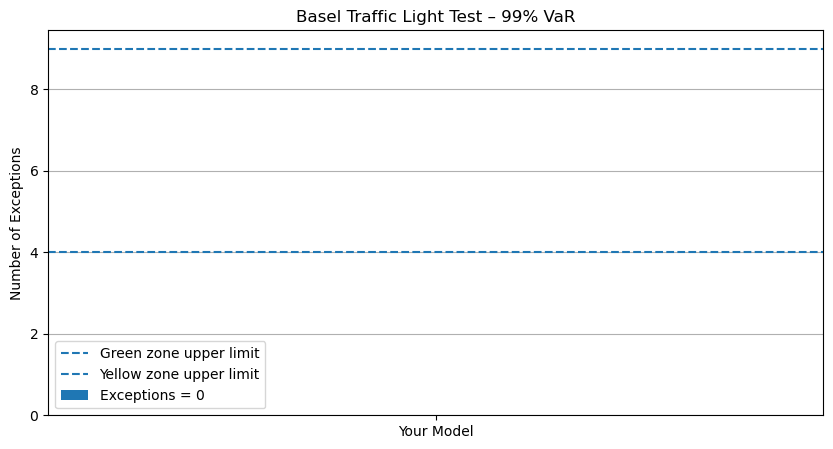

In [154]:
import matplotlib.pyplot as plt

# Basel zone boundaries for 250 observations
green_limit = 4
yellow_limit = 9

zones = ['Green', 'Yellow', 'Red']
limits = [green_limit, yellow_limit, 250]

plt.figure(figsize=(10, 5))

plt.bar(
    ['Your Model'],
    [basel_exceptions],
    label=f'Exceptions = {basel_exceptions}'
)

plt.axhline(
    green_limit,
    linestyle='--',
    label='Green zone upper limit'
)

plt.axhline(
    yellow_limit,
    linestyle='--',
    label='Yellow zone upper limit'
)

plt.title('Basel Traffic Light Test – 99% VaR')
plt.ylabel('Number of Exceptions')
plt.legend()
plt.grid(axis='y')

plt.show()

### Exception Timeline

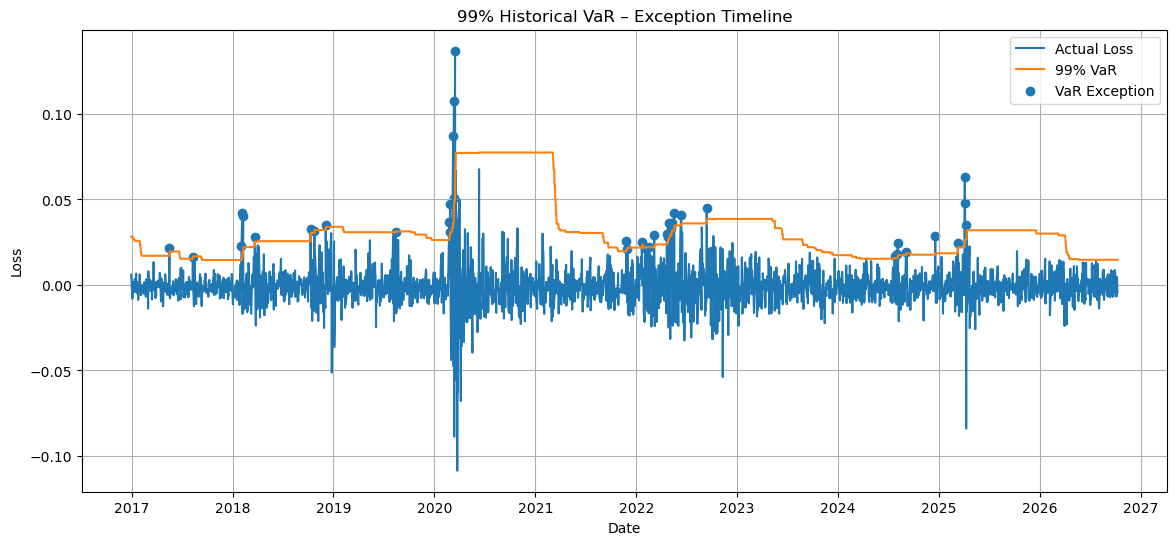

In [155]:
plt.figure(figsize=(14, 6))

plt.plot(
    basel_df.index,
    basel_df['Actual_Loss'],
    label='Actual Loss'
)

plt.plot(
    basel_df.index,
    basel_df['VaR_99'],
    label='99% VaR'
)

exceptions_99 = basel_df[basel_df['Exception']]

plt.scatter(
    exceptions_99.index,
    exceptions_99['Actual_Loss'],
    label='VaR Exception'
)

plt.title('99% Historical VaR – Exception Timeline')
plt.xlabel('Date')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### Create rolling EWMA/GARCH/GJR-GARCH VaR

In [156]:
# ============================================================
# PHASE 9 - MODEL COMPARISON
# Rolling EWMA, GARCH and GJR-GARCH VaR
# ============================================================

import numpy as np
import pandas as pd

confidence_level = 0.95
window = 750

# ------------------------------------------------------------
# 1. EWMA one-day-ahead volatility
# ------------------------------------------------------------

ewma_forecast_vol = ewma_volatility.shift(1)


# ------------------------------------------------------------
# 2. GARCH one-day-ahead volatility
# ------------------------------------------------------------

garch_forecast = garch_fit.forecast(
    horizon=1,
    reindex=True
)

garch_forecast_vol = (
    np.sqrt(garch_forecast.variance.iloc[:, 0]) / 100
)

# Forecast generated on previous day -> shift to target day
garch_forecast_vol = garch_forecast_vol.shift(1)


# ------------------------------------------------------------
# 3. GJR-GARCH one-day-ahead volatility
# ------------------------------------------------------------

gjr_forecast = gjr_fit.forecast(
    horizon=1,
    reindex=True
)

gjr_forecast_vol = (
    np.sqrt(gjr_forecast.variance.iloc[:, 0]) / 100
)

# Align previous-day forecast with today's return
gjr_forecast_vol = gjr_forecast_vol.shift(1)


print("EWMA forecast volatility:")
print(ewma_forecast_vol.dropna().tail())

print("\nGARCH forecast volatility:")
print(garch_forecast_vol.dropna().tail())

print("\nGJR-GARCH forecast volatility:")
print(gjr_forecast_vol.dropna().tail())

EWMA forecast volatility:
Date
2026-10-05    0.005733
2026-10-06    0.005609
2026-10-07    0.005678
2026-10-08    0.005620
2026-10-09    0.005495
dtype: float64

GARCH forecast volatility:
Series([], Name: h.1, dtype: float64)

GJR-GARCH forecast volatility:
Series([], Name: h.1, dtype: float64)


### Build the four rolling VaR models

In [157]:
# ============================================================
# BUILD ROLLING VAIR SERIES
# ============================================================

historical_var_list = []
ewma_var_list = []
garch_var_list = []
gjr_var_list = []

comparison_dates = []

for i in range(window, len(portfolio_returns)):

    current_date = portfolio_returns.index[i]

    # Current return
    current_return = portfolio_returns.iloc[i]

    # Previous 750 observations
    historical_returns = portfolio_returns.iloc[i-window:i]

    # --------------------------------------------------------
    # Historical Simulation VaR
    # --------------------------------------------------------

    historical_var = -np.percentile(
        historical_returns,
        5
    )

    # --------------------------------------------------------
    # EWMA-scaled Historical VaR
    # --------------------------------------------------------

    ewma_hist_vol = ewma_volatility.iloc[i-window:i]
    ewma_current_vol = ewma_forecast_vol.iloc[i]

    if ewma_current_vol > 0:

        ewma_scaled_returns = (
            historical_returns *
            (ewma_current_vol / ewma_hist_vol)
        )

        ewma_var = -np.percentile(
            ewma_scaled_returns.dropna(),
            5
        )

    else:
        ewma_var = np.nan


    # --------------------------------------------------------
    # GARCH-scaled Historical VaR
    # --------------------------------------------------------

    garch_hist_vol = garch_cond_vol.iloc[i-window:i]
    garch_current_vol = garch_forecast_vol.iloc[i]

    if garch_current_vol > 0:

        garch_scaled_returns = (
            historical_returns *
            (garch_current_vol / garch_hist_vol)
        )

        garch_var = -np.percentile(
            garch_scaled_returns.dropna(),
            5
        )

    else:
        garch_var = np.nan


    # --------------------------------------------------------
    # GJR-GARCH-scaled Historical VaR
    # --------------------------------------------------------

    gjr_hist_vol = gjr_cond_vol.iloc[i-window:i]
    gjr_current_vol = gjr_forecast_vol.iloc[i]

    if gjr_current_vol > 0:

        gjr_scaled_returns = (
            historical_returns *
            (gjr_current_vol / gjr_hist_vol)
        )

        gjr_var = -np.percentile(
            gjr_scaled_returns.dropna(),
            5
        )

    else:
        gjr_var = np.nan


    # Store results
    comparison_dates.append(current_date)

    historical_var_list.append(historical_var)
    ewma_var_list.append(ewma_var)
    garch_var_list.append(garch_var)
    gjr_var_list.append(gjr_var)


# ------------------------------------------------------------
# Create comparison dataframe
# ------------------------------------------------------------

model_var_df = pd.DataFrame({

    'Actual_Return': portfolio_returns.loc[comparison_dates].values,

    'Historical_VaR': historical_var_list,

    'EWMA_VaR': ewma_var_list,

    'GARCH_VaR': garch_var_list,

    'GJR_GARCH_VaR': gjr_var_list

}, index=comparison_dates)


# Convert return VaR into ₹ loss
var_columns = [
    'Historical_VaR',
    'EWMA_VaR',
    'GARCH_VaR',
    'GJR_GARCH_VaR'
]

model_var_df[var_columns] = (
    model_var_df[var_columns]
    * initial_portfolio_value
)


# Actual loss in ₹
model_var_df['Actual_Loss'] = (
    -model_var_df['Actual_Return']
    * initial_portfolio_value
)


print(model_var_df.head())

print("\nShape:")
print(model_var_df.shape)

            Actual_Return  Historical_VaR      EWMA_VaR  GARCH_VaR  \
2018-12-27       0.008214    15377.288595  30635.054347        NaN   
2018-12-28       0.001394    15377.288595  29861.446632        NaN   
2018-12-31       0.009255    15377.288595  28956.474191        NaN   
2019-01-02       0.000131    15163.511351  28288.537173        NaN   
2019-01-03      -0.025405    15163.511351  27426.798142        NaN   

            GJR_GARCH_VaR   Actual_Loss  
2018-12-27            NaN  -8214.366439  
2018-12-28            NaN  -1393.716510  
2018-12-31            NaN  -9255.240177  
2019-01-02            NaN   -130.523805  
2019-01-03            NaN  25404.880781  

Shape:
(1957, 6)


### Calculate exceptions

In [158]:
# ============================================================
# EXCEPTIONS FOR EACH MODEL
# ============================================================

model_names = {
    'Historical_VaR': 'Historical',
    'EWMA_VaR': 'EWMA',
    'GARCH_VaR': 'GARCH',
    'GJR_GARCH_VaR': 'GJR-GARCH'
}

for column in model_names.keys():

    exception_column = column + '_Exception'

    model_var_df[exception_column] = (
        model_var_df['Actual_Loss'] >
        model_var_df[column]
    )


# Display exception counts

exception_summary = {}

for column, name in model_names.items():

    exception_column = column + '_Exception'

    exceptions = model_var_df[exception_column].sum()

    observations = model_var_df[column].notna().sum()

    ratio = exceptions / observations

    exception_summary[name] = {
        'Exceptions': exceptions,
        'Observations': observations,
        'Exception Ratio': ratio
    }


exception_summary_df = pd.DataFrame(exception_summary).T

exception_summary_df

C:\Users\HP\AppData\Local\Temp\ipykernel_4376\3969285144.py:34: RuntimeWarning: invalid value encountered in scalar divide
  ratio = exceptions / observations


,Exceptions,Observations,Exception Ratio
Historical,86.0,1957.0,0.043945
EWMA,118.0,1957.0,0.060296
GARCH,0.0,0.0,NaN
GJR-GARCH,0.0,0.0,NaN


### Average VaR and VaR volatility

In [159]:
# ============================================================
# AVERAGE VaR AND VaR VOLATILITY
# ============================================================

comparison_metrics = {}

for column, name in model_names.items():

    var_series = model_var_df[column].dropna()

    comparison_metrics[name] = {

        'Average VaR (₹)': var_series.mean(),

        'VaR Volatility (₹)': var_series.std(),

        'Minimum VaR (₹)': var_series.min(),

        'Maximum VaR (₹)': var_series.max()
    }


var_metrics_df = pd.DataFrame(comparison_metrics).T

var_metrics_df

,Average VaR (₹),VaR Volatility (₹),Minimum VaR (₹),Maximum VaR (₹)
Historical,18187.884582,3581.992066,12587.945976,24892.437484
EWMA,17281.031697,11233.175227,6440.704598,94248.318482
GARCH,NaN,NaN,NaN,NaN
GJR-GARCH,NaN,NaN,NaN,NaN


### Expected Shortfall

In [160]:
# ============================================================
# EXPECTED SHORTFALL
# ============================================================

es_results = {}

for column, name in model_names.items():

    var_series = model_var_df[column]

    valid_data = model_var_df[
        var_series.notna()
    ].copy()

    tail_losses = valid_data[
        valid_data['Actual_Loss'] >
        valid_data[column]
    ]['Actual_Loss']

    if len(tail_losses) > 0:

        es = tail_losses.mean()

    else:

        es = np.nan

    es_results[name] = es


es_df = pd.DataFrame.from_dict(
    es_results,
    orient='index',
    columns=['Expected Shortfall (₹)']
)

es_df

,Expected Shortfall (₹)
Historical,30608.451353
EWMA,22956.544725
GARCH,NaN
GJR-GARCH,NaN


### Worst daily loss

In [161]:
# ============================================================
# WORST DAILY LOSS
# ============================================================

worst_daily_loss = model_var_df['Actual_Loss'].max()

print(
    f"Worst Daily Portfolio Loss: "
    f"₹{worst_daily_loss:,.2f}"
)

Worst Daily Portfolio Loss: ₹136,940.78


### Create the final Phase 9 comparison table

In [162]:
# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

final_comparison = pd.DataFrame(index=model_names.values())

for column, name in model_names.items():

    var_series = model_var_df[column].dropna()

    exception_column = column + '_Exception'

    exceptions = (
        model_var_df[exception_column]
        .sum()
    )

    observations = (
        model_var_df[column]
        .notna()
        .sum()
    )

    exception_ratio = exceptions / observations

    tail_losses = model_var_df.loc[
        model_var_df[exception_column],
        'Actual_Loss'
    ]

    expected_shortfall = (
        tail_losses.mean()
        if len(tail_losses) > 0
        else np.nan
    )

    final_comparison.loc[name, 'Exceptions'] = exceptions

    final_comparison.loc[name, 'Exception Ratio'] = (
        exception_ratio
    )

    final_comparison.loc[name, 'Average VaR (₹)'] = (
        var_series.mean()
    )

    final_comparison.loc[name, 'VaR Volatility (₹)'] = (
        var_series.std()
    )

    final_comparison.loc[name, 'Expected Shortfall (₹)'] = (
        expected_shortfall
    )

    final_comparison.loc[name, 'Worst Daily Loss (₹)'] = (
        worst_daily_loss
    )


final_comparison

C:\Users\HP\AppData\Local\Temp\ipykernel_4376\2500272740.py:24: RuntimeWarning: invalid value encountered in scalar divide
  exception_ratio = exceptions / observations
C:\Users\HP\AppData\Local\Temp\ipykernel_4376\2500272740.py:24: RuntimeWarning: invalid value encountered in scalar divide
  exception_ratio = exceptions / observations


,Exceptions,Exception Ratio,Average VaR (₹),VaR Volatility (₹),Expected Shortfall (₹),Worst Daily Loss (₹)
Historical,86.0,0.043945,18187.884582,3581.992066,30608.451353,136940.777649
EWMA,118.0,0.060296,17281.031697,11233.175227,22956.544725,136940.777649
GARCH,0.0,NaN,NaN,NaN,NaN,136940.777649
GJR-GARCH,0.0,NaN,NaN,NaN,NaN,136940.777649


### VaR Model Comparison Chart

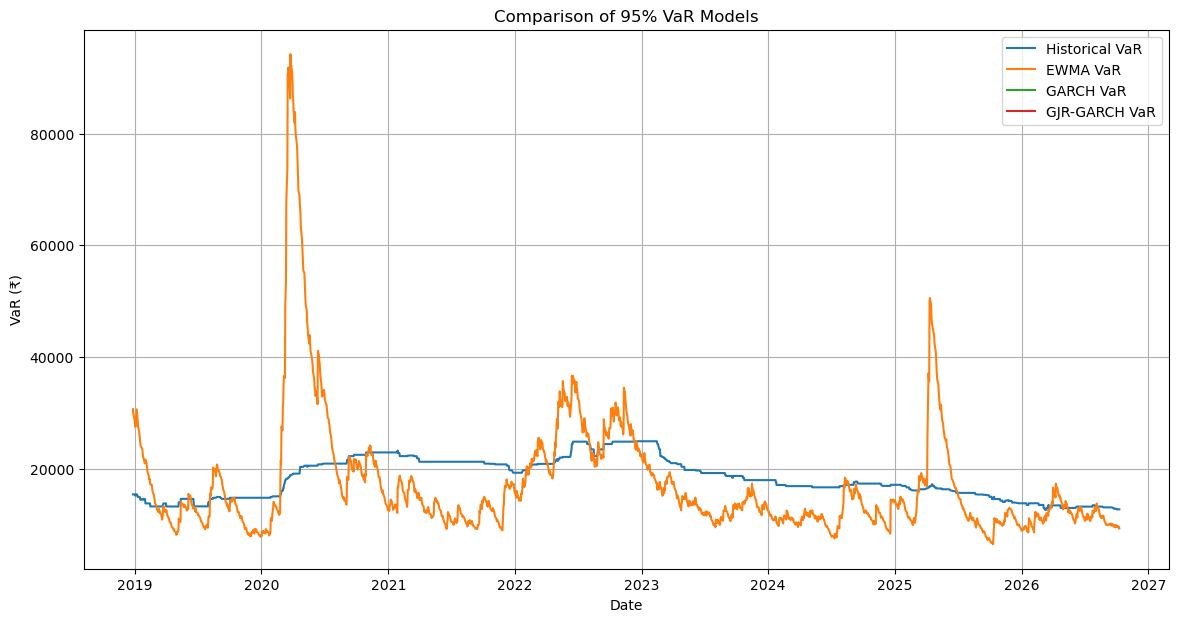

In [163]:
# ============================================================
# VaR MODEL COMPARISON
# ============================================================

plt.figure(figsize=(14, 7))

plt.plot(
    model_var_df.index,
    model_var_df['Historical_VaR'],
    label='Historical VaR'
)

plt.plot(
    model_var_df.index,
    model_var_df['EWMA_VaR'],
    label='EWMA VaR'
)

plt.plot(
    model_var_df.index,
    model_var_df['GARCH_VaR'],
    label='GARCH VaR'
)

plt.plot(
    model_var_df.index,
    model_var_df['GJR_GARCH_VaR'],
    label='GJR-GARCH VaR'
)

plt.title(
    'Comparison of 95% VaR Models'
)

plt.xlabel('Date')
plt.ylabel('VaR (₹)')

plt.legend()
plt.grid(True)

plt.show()

### Actual Loss vs all VaR models

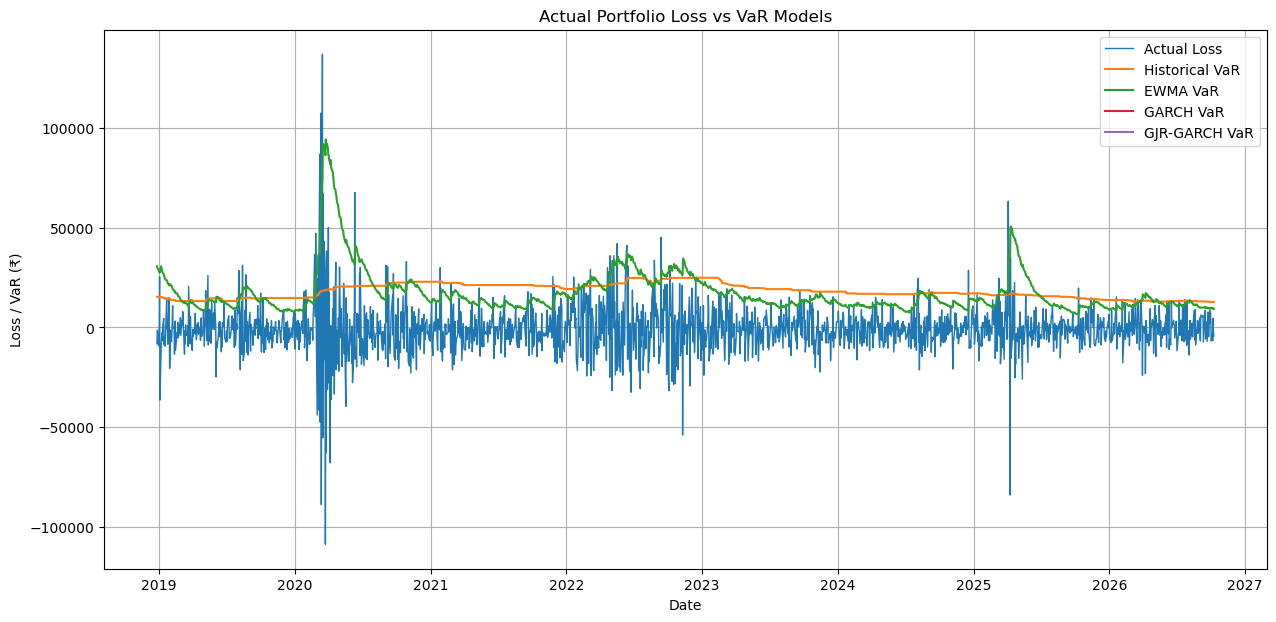

In [164]:
# ============================================================
# ACTUAL LOSS VS ALL VAR MODELS
# ============================================================

plt.figure(figsize=(15, 7))

plt.plot(
    model_var_df.index,
    model_var_df['Actual_Loss'],
    label='Actual Loss',
    linewidth=1
)

plt.plot(
    model_var_df.index,
    model_var_df['Historical_VaR'],
    label='Historical VaR'
)

plt.plot(
    model_var_df.index,
    model_var_df['EWMA_VaR'],
    label='EWMA VaR'
)

plt.plot(
    model_var_df.index,
    model_var_df['GARCH_VaR'],
    label='GARCH VaR'
)

plt.plot(
    model_var_df.index,
    model_var_df['GJR_GARCH_VaR'],
    label='GJR-GARCH VaR'
)

plt.title(
    'Actual Portfolio Loss vs VaR Models'
)

plt.xlabel('Date')
plt.ylabel('Loss / VaR (₹)')

plt.legend()
plt.grid(True)

plt.show()

### Exceptions by model

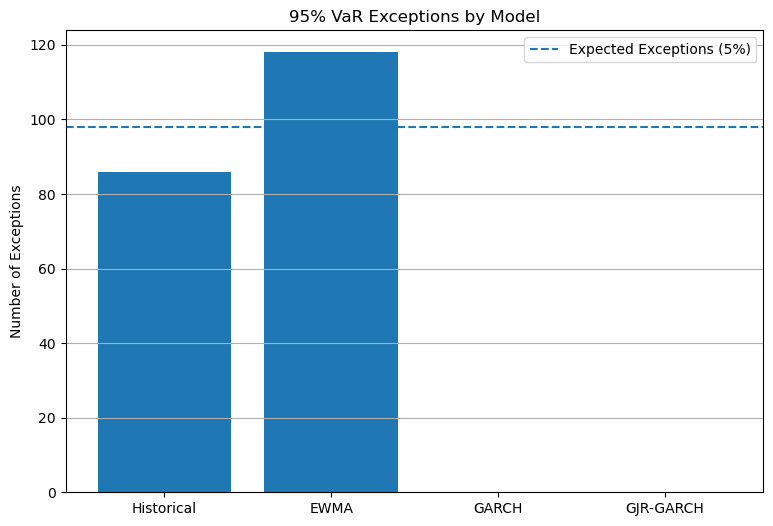

In [165]:
# ============================================================
# EXCEPTIONS BY MODEL
# ============================================================

exception_counts = []

for column, name in model_names.items():

    exception_column = column + '_Exception'

    exception_counts.append(
        model_var_df[exception_column].sum()
    )


plt.figure(figsize=(9, 6))

plt.bar(
    list(model_names.values()),
    exception_counts
)

plt.axhline(
    len(model_var_df) * 0.05,
    linestyle='--',
    label='Expected Exceptions (5%)'
)

plt.title(
    '95% VaR Exceptions by Model'
)

plt.ylabel('Number of Exceptions')

plt.legend()
plt.grid(axis='y')

plt.show()

In [166]:
# ============================================================
# PHASE 9 - GARCH & GJR-GARCH ROLLING FORECAST VOLATILITY
# ============================================================

# GARCH one-step-ahead forecasts
garch_forecast_all = garch_fit.forecast(
    horizon=1,
    start=0,
    reindex=True
)

garch_forecast_vol = (
    np.sqrt(garch_forecast_all.variance.iloc[:, 0]) / 100
)

# Forecast made at t is used for return at t+1
garch_forecast_vol = garch_forecast_vol.shift(1)


# GJR-GARCH one-step-ahead forecasts
gjr_forecast_all = gjr_fit.forecast(
    horizon=1,
    start=0,
    reindex=True
)

gjr_forecast_vol = (
    np.sqrt(gjr_forecast_all.variance.iloc[:, 0]) / 100
)

# Forecast made at t is used for return at t+1
gjr_forecast_vol = gjr_forecast_vol.shift(1)


print("GARCH forecast volatility:")
print(garch_forecast_vol.dropna().tail())

print("\nGJR-GARCH forecast volatility:")
print(gjr_forecast_vol.dropna().tail())

GARCH forecast volatility:
Date
2026-10-05    0.006817
2026-10-06    0.006561
2026-10-07    0.006740
2026-10-08    0.006628
2026-10-09    0.006388
Name: h.1, dtype: float64

GJR-GARCH forecast volatility:
Date
2026-10-05    0.007385
2026-10-06    0.007008
2026-10-07    0.006787
2026-10-08    0.006903
2026-10-09    0.006582
Name: h.1, dtype: float64


### Rebuild the four VaR series

In [167]:
# ============================================================
# ROLLING 95% VAR - FOUR MODELS
# ============================================================

window = 750

historical_var_list = []
ewma_var_list = []
garch_var_list = []
gjr_var_list = []

comparison_dates = []


for i in range(window, len(portfolio_returns)):

    current_date = portfolio_returns.index[i]

    # Previous 750 returns only
    historical_returns = portfolio_returns.iloc[i-window:i]


    # ========================================================
    # HISTORICAL SIMULATION
    # ========================================================

    historical_var = -np.percentile(
        historical_returns,
        5
    )


    # ========================================================
    # EWMA
    # ========================================================

    ewma_current_vol = ewma_forecast_vol.iloc[i]

    ewma_hist_vol = ewma_volatility.iloc[i-window:i]

    if (
        pd.notna(ewma_current_vol)
        and (ewma_hist_vol > 0).all()
    ):

        ewma_scaled_returns = (
            historical_returns *
            (ewma_current_vol / ewma_hist_vol)
        )

        ewma_var = -np.percentile(
            ewma_scaled_returns.dropna(),
            5
        )

    else:

        ewma_var = np.nan


    # ========================================================
    # GARCH
    # ========================================================

    garch_current_vol = garch_forecast_vol.iloc[i]

    garch_hist_vol = garch_cond_vol.iloc[i-window:i]

    if (
        pd.notna(garch_current_vol)
        and (garch_hist_vol > 0).all()
    ):

        garch_scaled_returns = (
            historical_returns *
            (garch_current_vol / garch_hist_vol)
        )

        garch_var = -np.percentile(
            garch_scaled_returns.dropna(),
            5
        )

    else:

        garch_var = np.nan


    # ========================================================
    # GJR-GARCH
    # ========================================================

    gjr_current_vol = gjr_forecast_vol.iloc[i]

    gjr_hist_vol = gjr_cond_vol.iloc[i-window:i]

    if (
        pd.notna(gjr_current_vol)
        and (gjr_hist_vol > 0).all()
    ):

        gjr_scaled_returns = (
            historical_returns *
            (gjr_current_vol / gjr_hist_vol)
        )

        gjr_var = -np.percentile(
            gjr_scaled_returns.dropna(),
            5
        )

    else:

        gjr_var = np.nan


    comparison_dates.append(current_date)

    historical_var_list.append(historical_var)
    ewma_var_list.append(ewma_var)
    garch_var_list.append(garch_var)
    gjr_var_list.append(gjr_var)


# ============================================================
# CREATE DATAFRAME
# ============================================================

model_var_df = pd.DataFrame({

    'Actual_Return':
        portfolio_returns.loc[comparison_dates].values,

    'Historical_VaR':
        historical_var_list,

    'EWMA_VaR':
        ewma_var_list,

    'GARCH_VaR':
        garch_var_list,

    'GJR_GARCH_VaR':
        gjr_var_list

}, index=comparison_dates)


# Convert VaR from return units to ₹
var_columns = [
    'Historical_VaR',
    'EWMA_VaR',
    'GARCH_VaR',
    'GJR_GARCH_VaR'
]

model_var_df[var_columns] = (
    model_var_df[var_columns]
    * initial_portfolio_value
)


# Actual loss in ₹
model_var_df['Actual_Loss'] = (
    -model_var_df['Actual_Return']
    * initial_portfolio_value
)


print(model_var_df.tail())

print("\nShape:", model_var_df.shape)

print("\nMissing values:")
print(model_var_df[var_columns].isna().sum())

            Actual_Return  Historical_VaR     EWMA_VaR     GARCH_VaR  \
2026-10-05       0.003088     12694.65061  9661.838477  10935.691645   
2026-10-06       0.006667     12694.65061  9453.869876  10525.670173   
2026-10-07      -0.004610     12694.65061  9570.222175  10811.633379   
2026-10-08       0.002906     12694.65061  9471.844942  10632.267763   
2026-10-09       0.004300     12694.65061  9261.337152  10247.870963   

            GJR_GARCH_VaR  Actual_Loss  
2026-10-05   11738.922140 -3088.374041  
2026-10-06   11138.930864 -6667.208481  
2026-10-07   10787.546563  4609.988406  
2026-10-08   10972.296706 -2906.192179  
2026-10-09   10462.308470 -4300.231422  

Shape: (1957, 6)

Missing values:
Historical_VaR    0
EWMA_VaR          0
GARCH_VaR         0
GJR_GARCH_VaR     0
dtype: int64


### Check whether all four models are now populated

In [168]:
model_var_df[
    [
        'Historical_VaR',
        'EWMA_VaR',
        'GARCH_VaR',
        'GJR_GARCH_VaR'
    ]
].describe()

,Historical_VaR,EWMA_VaR,GARCH_VaR,GJR_GARCH_VaR
count,1957.000000,1957.000000,1957.000000,1957.000000
mean,18187.884582,17281.031697,17631.851908,17460.606033
std,3581.992066,11233.175227,10968.114774,11842.293544
min,12587.945976,6440.704598,7993.933085,7325.932478
25%,14765.251597,11115.088763,11821.072322,11263.716844
50%,17666.533487,13519.472562,14374.224978,14066.538261
75%,21220.448479,19253.826948,19656.628744,19509.131508
max,24892.437484,94248.318482,126144.920122,143793.585104


In [169]:
print(
    model_var_df[
        [
            'Historical_VaR',
            'EWMA_VaR',
            'GARCH_VaR',
            'GJR_GARCH_VaR'
        ]
    ].notna().sum()
)

Historical_VaR    1957
EWMA_VaR          1957
GARCH_VaR         1957
GJR_GARCH_VaR     1957
dtype: int64


In [170]:
print(model_var_df[var_columns].notna().sum())

Historical_VaR    1957
EWMA_VaR          1957
GARCH_VaR         1957
GJR_GARCH_VaR     1957
dtype: int64


In [171]:
model_var_df[var_columns].describe()

,Historical_VaR,EWMA_VaR,GARCH_VaR,GJR_GARCH_VaR
count,1957.000000,1957.000000,1957.000000,1957.000000
mean,18187.884582,17281.031697,17631.851908,17460.606033
std,3581.992066,11233.175227,10968.114774,11842.293544
min,12587.945976,6440.704598,7993.933085,7325.932478
25%,14765.251597,11115.088763,11821.072322,11263.716844
50%,17666.533487,13519.472562,14374.224978,14066.538261
75%,21220.448479,19253.826948,19656.628744,19509.131508
max,24892.437484,94248.318482,126144.920122,143793.585104


### Exceptions + Expected Shortfall

In [172]:
# ============================================================
# PHASE 9 - FINAL MODEL COMPARISON
# Exceptions + Expected Shortfall
# ============================================================

models = {
    'Historical': 'Historical_VaR',
    'EWMA': 'EWMA_VaR',
    'GARCH': 'GARCH_VaR',
    'GJR-GARCH': 'GJR_GARCH_VaR'
}

comparison_results = []

for model_name, var_col in models.items():

    data = model_var_df[
        ['Actual_Loss', var_col]
    ].dropna().copy()

    # Exception
    data['Exception'] = (
        data['Actual_Loss'] > data[var_col]
    )

    exceptions = data['Exception'].sum()

    observations = len(data)

    exception_ratio = exceptions / observations

    # Expected exceptions at 95%
    expected_exceptions = observations * 0.05

    # Expected Shortfall
    tail_losses = data.loc[
        data['Exception'],
        'Actual_Loss'
    ]

    expected_shortfall = (
        tail_losses.mean()
        if len(tail_losses) > 0
        else np.nan
    )

    comparison_results.append({

        'Model': model_name,

        'Exceptions': exceptions,

        'Expected Exceptions': expected_exceptions,

        'Exception Ratio': exception_ratio,

        'Average VaR (₹)': data[var_col].mean(),

        'VaR Volatility (₹)': data[var_col].std(),

        'Worst Daily Loss (₹)': data['Actual_Loss'].max(),

        'Expected Shortfall (₹)': expected_shortfall
    })


final_comparison = pd.DataFrame(
    comparison_results
).set_index('Model')


final_comparison

,Exceptions,Expected Exceptions,Exception Ratio,Average VaR (₹),VaR Volatility (₹),Worst Daily Loss (₹),Expected Shortfall (₹)
Model,,,,,,,
Historical,86,97.85,0.043945,18187.884582,3581.992066,136940.777649,30608.451353
EWMA,118,97.85,0.060296,17281.031697,11233.175227,136940.777649,22956.544725
GARCH,100,97.85,0.051099,17631.851908,10968.114774,136940.777649,24473.458409
GJR-GARCH,108,97.85,0.055187,17460.606033,11842.293544,136940.777649,23453.778071


### Add Kupiec POF for every model

In [173]:
# ============================================================
# KUPIEC POF TEST - ALL MODELS
# ============================================================

from scipy.stats import chi2

for model_name, var_col in models.items():

    data = model_var_df[
        ['Actual_Loss', var_col]
    ].dropna()

    exceptions = (
        data['Actual_Loss'] > data[var_col]
    )

    T = len(data)
    x = exceptions.sum()

    p = 0.05
    phat = x / T

    # Avoid log(0)
    phat = np.clip(phat, 1e-10, 1 - 1e-10)

    LR_POF = -2 * np.log(
        (
            ((1 - p) ** (T - x)) *
            (p ** x)
        )
        /
        (
            ((1 - phat) ** (T - x)) *
            (phat ** x)
        )
    )

    p_value = chi2.sf(
        LR_POF,
        df=1
    )

    final_comparison.loc[
        model_name,
        'Kupiec LR POF'
    ] = LR_POF

    final_comparison.loc[
        model_name,
        'Kupiec P-value'
    ] = p_value


final_comparison

,Exceptions,Expected Exceptions,Exception Ratio,Average VaR (₹),VaR Volatility (₹),Worst Daily Loss (₹),Expected Shortfall (₹),Kupiec LR POF,Kupiec P-value
Model,,,,,,,,,
Historical,86,97.85,0.043945,18187.884582,3581.992066,136940.777649,30608.451353,1.572166,0.209893
EWMA,118,97.85,0.060296,17281.031697,11233.175227,136940.777649,22956.544725,4.109932,0.042632
GARCH,100,97.85,0.051099,17631.851908,10968.114774,136940.777649,24473.458409,0.049386,0.824136
GJR-GARCH,108,97.85,0.055187,17460.606033,11842.293544,136940.777649,23453.778071,1.073750,0.300100


### Add Christoffersen Independence Test

In [174]:
# ============================================================
# CHRISTOFFERSEN INDEPENDENCE TEST - ALL MODELS
# ============================================================

for model_name, var_col in models.items():

    data = model_var_df[
        ['Actual_Loss', var_col]
    ].dropna()

    exceptions = (
        data['Actual_Loss'] > data[var_col]
    ).astype(int)

    transition_df = pd.DataFrame({
        'Previous': exceptions.shift(1),
        'Current': exceptions
    }).dropna()

    n00 = (
        (transition_df['Previous'] == 0) &
        (transition_df['Current'] == 0)
    ).sum()

    n01 = (
        (transition_df['Previous'] == 0) &
        (transition_df['Current'] == 1)
    ).sum()

    n10 = (
        (transition_df['Previous'] == 1) &
        (transition_df['Current'] == 0)
    ).sum()

    n11 = (
        (transition_df['Previous'] == 1) &
        (transition_df['Current'] == 1)
    ).sum()

    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0

    total_exceptions = n01 + n11
    total_transitions = n00 + n01 + n10 + n11

    pi = total_exceptions / total_transitions

    # Handle zero probabilities safely
    def safe_log_likelihood(probabilities):

        result = 0

        for count, probability in probabilities:

            if count > 0:

                probability = np.clip(
                    probability,
                    1e-10,
                    1 - 1e-10
                )

                result += count * np.log(probability)

        return result


    log_L_ind = safe_log_likelihood([
        (n00, 1 - pi),
        (n10, 1 - pi),
        (n01, pi),
        (n11, pi)
    ])

    log_L_dep = safe_log_likelihood([
        (n00, 1 - pi01),
        (n01, pi01),
        (n10, 1 - pi11),
        (n11, pi11)
    ])

    LR_ind = -2 * (
        log_L_ind - log_L_dep
    )

    p_value_ind = chi2.sf(
        LR_ind,
        df=1
    )

    final_comparison.loc[
        model_name,
        'Christoffersen Independence p-value'
    ] = p_value_ind


final_comparison

,Exceptions,Expected Exceptions,Exception Ratio,Average VaR (₹),VaR Volatility (₹),Worst Daily Loss (₹),Expected Shortfall (₹),Kupiec LR POF,Kupiec P-value,Christoffersen Independence p-value
Model,,,,,,,,,,
Historical,86,97.85,0.043945,18187.884582,3581.992066,136940.777649,30608.451353,1.572166,0.209893,0.004677
EWMA,118,97.85,0.060296,17281.031697,11233.175227,136940.777649,22956.544725,4.109932,0.042632,0.729703
GARCH,100,97.85,0.051099,17631.851908,10968.114774,136940.777649,24473.458409,0.049386,0.824136,0.958053
GJR-GARCH,108,97.85,0.055187,17460.606033,11842.293544,136940.777649,23453.778071,1.073750,0.300100,0.660925


### Conditional Coverage

In [175]:
# ============================================================
# CHRISTOFFERSEN CONDITIONAL COVERAGE
# ============================================================

for model_name in models.keys():

    kupiec_p = final_comparison.loc[
        model_name,
        'Kupiec P-value'
    ]

    # We need LR values
    # Reconstruct from stored results

    var_col = models[model_name]

    data = model_var_df[
        ['Actual_Loss', var_col]
    ].dropna()

    exceptions = (
        data['Actual_Loss'] > data[var_col]
    ).astype(int)

    T = len(exceptions)
    x = exceptions.sum()

    p = 0.05
    phat = x / T

    phat = np.clip(
        phat,
        1e-10,
        1 - 1e-10
    )

    LR_POF = -2 * np.log(
        (
            ((1-p)**(T-x)) * (p**x)
        )
        /
        (
            ((1-phat)**(T-x)) *
            (phat**x)
        )
    )

    transition_df = pd.DataFrame({
        'Previous': exceptions.shift(1),
        'Current': exceptions
    }).dropna()

    n00 = (
        (transition_df['Previous'] == 0) &
        (transition_df['Current'] == 0)
    ).sum()

    n01 = (
        (transition_df['Previous'] == 0) &
        (transition_df['Current'] == 1)
    ).sum()

    n10 = (
        (transition_df['Previous'] == 1) &
        (transition_df['Current'] == 0)
    ).sum()

    n11 = (
        (transition_df['Previous'] == 1) &
        (transition_df['Current'] == 1)
    ).sum()

    pi01 = n01 / (n00+n01) if n00+n01 > 0 else 0
    pi11 = n11 / (n10+n11) if n10+n11 > 0 else 0

    pi = (n01+n11) / (
        n00+n01+n10+n11
    )

    log_L_ind = safe_log_likelihood([
        (n00, 1-pi),
        (n10, 1-pi),
        (n01, pi),
        (n11, pi)
    ])

    log_L_dep = safe_log_likelihood([
        (n00, 1-pi01),
        (n01, pi01),
        (n10, 1-pi11),
        (n11, pi11)
    ])

    LR_ind = -2 * (
        log_L_ind - log_L_dep
    )

    LR_CC = LR_POF + LR_ind

    p_value_cc = chi2.sf(
        LR_CC,
        df=2
    )

    final_comparison.loc[
        model_name,
        'Conditional Coverage p-value'
    ] = p_value_cc


final_comparison

,Exceptions,Expected Exceptions,Exception Ratio,Average VaR (₹),VaR Volatility (₹),Worst Daily Loss (₹),Expected Shortfall (₹),Kupiec LR POF,Kupiec P-value,Christoffersen Independence p-value,Conditional Coverage p-value
Model,,,,,,,,,,,
Historical,86,97.85,0.043945,18187.884582,3581.992066,136940.777649,30608.451353,1.572166,0.209893,0.004677,0.008344
EWMA,118,97.85,0.060296,17281.031697,11233.175227,136940.777649,22956.544725,4.109932,0.042632,0.729703,0.120675
GARCH,100,97.85,0.051099,17631.851908,10968.114774,136940.777649,24473.458409,0.049386,0.824136,0.958053,0.974261
GJR-GARCH,108,97.85,0.055187,17460.606033,11842.293544,136940.777649,23453.778071,1.073750,0.300100,0.660925,0.530956


In [176]:
# ============================================================
# CLEAN FINAL TABLE
# ============================================================

display(
    final_comparison.round(4)
)

,Exceptions,Expected Exceptions,Exception Ratio,Average VaR (₹),VaR Volatility (₹),Worst Daily Loss (₹),Expected Shortfall (₹),Kupiec LR POF,Kupiec P-value,Christoffersen Independence p-value,Conditional Coverage p-value
Model,,,,,,,,,,,
Historical,86,97.85,0.0439,18187.8846,3581.9921,136940.7776,30608.4514,1.5722,0.2099,0.0047,0.0083
EWMA,118,97.85,0.0603,17281.0317,11233.1752,136940.7776,22956.5447,4.1099,0.0426,0.7297,0.1207
GARCH,100,97.85,0.0511,17631.8519,10968.1148,136940.7776,24473.4584,0.0494,0.8241,0.9581,0.9743
GJR-GARCH,108,97.85,0.0552,17460.6060,11842.2935,136940.7776,23453.7781,1.0738,0.3001,0.6609,0.5310


### VaR Model Comparison

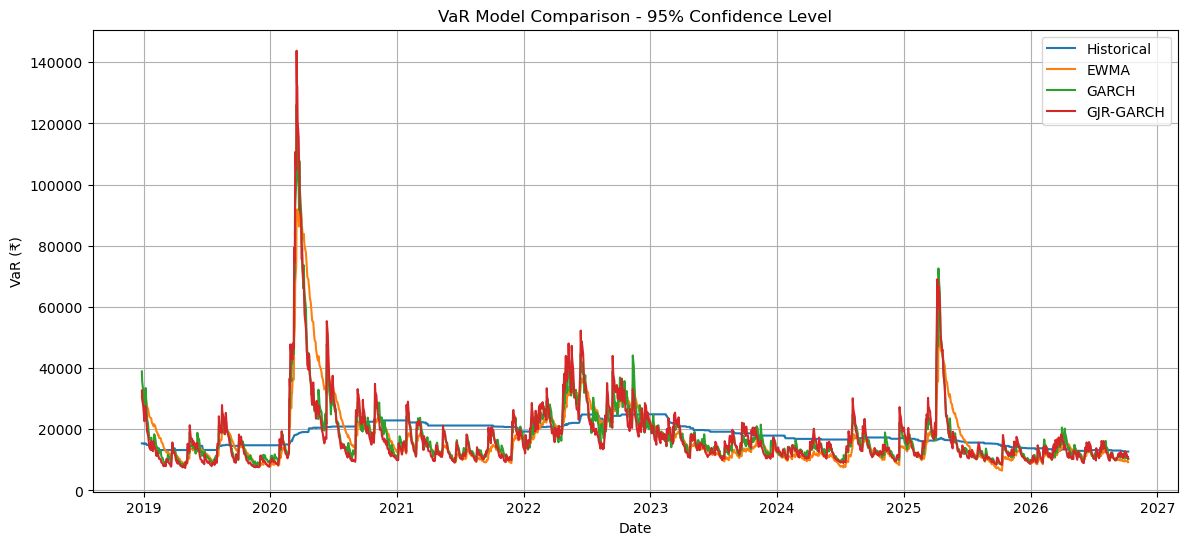

In [177]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    model_var_df.index,
    model_var_df['Historical_VaR'],
    label='Historical'
)

plt.plot(
    model_var_df.index,
    model_var_df['EWMA_VaR'],
    label='EWMA'
)

plt.plot(
    model_var_df.index,
    model_var_df['GARCH_VaR'],
    label='GARCH'
)

plt.plot(
    model_var_df.index,
    model_var_df['GJR_GARCH_VaR'],
    label='GJR-GARCH'
)

plt.title('VaR Model Comparison - 95% Confidence Level')
plt.xlabel('Date')
plt.ylabel('VaR (₹)')
plt.legend()
plt.grid(True)
plt.show()

### Actual Loss vs VaR

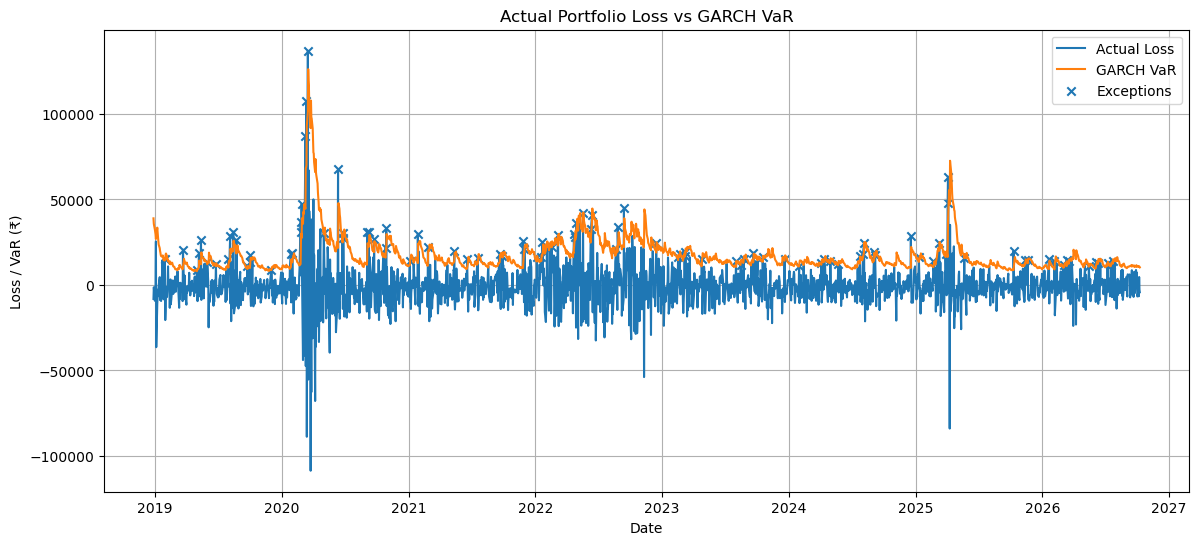

In [178]:
plt.figure(figsize=(14, 6))

plt.plot(
    model_var_df.index,
    model_var_df['Actual_Loss'],
    label='Actual Loss'
)

plt.plot(
    model_var_df.index,
    model_var_df['GARCH_VaR'],
    label='GARCH VaR'
)

exceptions = (
    model_var_df['Actual_Loss'] >
    model_var_df['GARCH_VaR']
)

plt.scatter(
    model_var_df.index[exceptions],
    model_var_df.loc[exceptions, 'Actual_Loss'],
    marker='x',
    label='Exceptions'
)

plt.title('Actual Portfolio Loss vs GARCH VaR')
plt.xlabel('Date')
plt.ylabel('Loss / VaR (₹)')
plt.legend()
plt.grid(True)
plt.show()

### Exceptions by Model

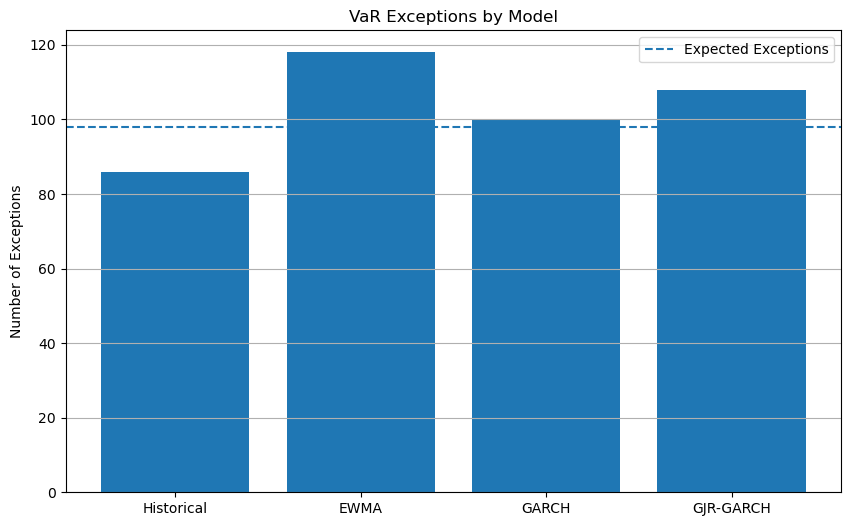

In [179]:
exception_counts = final_comparison['Exceptions']

plt.figure(figsize=(10, 6))

plt.bar(
    exception_counts.index,
    exception_counts.values
)

plt.axhline(
    final_comparison['Expected Exceptions'].iloc[0],
    linestyle='--',
    label='Expected Exceptions'
)

plt.title('VaR Exceptions by Model')
plt.ylabel('Number of Exceptions')
plt.legend()
plt.grid(axis='y')
plt.show()

### Exception Ratio

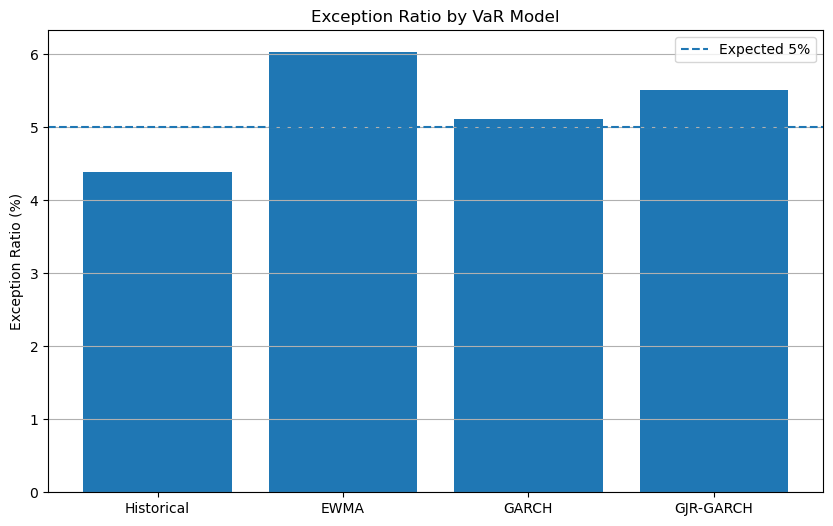

In [180]:
plt.figure(figsize=(10, 6))

plt.bar(
    final_comparison.index,
    final_comparison['Exception Ratio'] * 100
)

plt.axhline(
    5,
    linestyle='--',
    label='Expected 5%'
)

plt.title('Exception Ratio by VaR Model')
plt.ylabel('Exception Ratio (%)')
plt.legend()
plt.grid(axis='y')
plt.show()

### Backtesting p-values

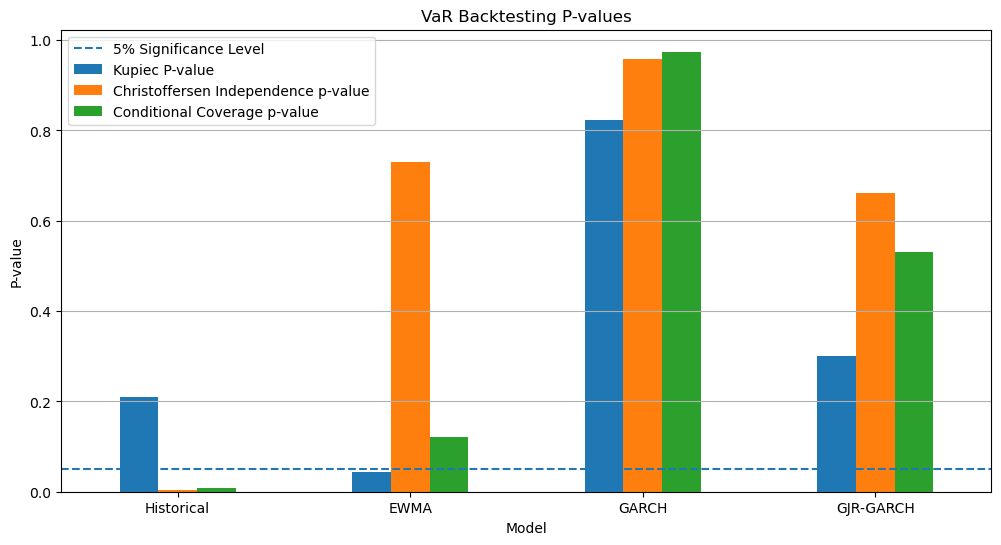

In [181]:
pvalue_df = final_comparison[
    [
        'Kupiec P-value',
        'Christoffersen Independence p-value',
        'Conditional Coverage p-value'
    ]
]

ax = pvalue_df.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.axhline(
    0.05,
    linestyle='--',
    label='5% Significance Level'
)

plt.title('VaR Backtesting P-values')
plt.ylabel('P-value')
plt.legend()
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

### Phase 10 – Stress Testing

In [182]:
# Check important portfolio variables
print("Stock prices shape:", stock_prices.shape)

print("\nNumber of stocks:", len(stock_prices.columns))

print("\nFirst 10 stocks:")
print(stock_prices.columns[:10])

print("\nWeights:")
print(weights)

print("\nSum of weights:", weights.sum())

Stock prices shape: (2708, 50)

Number of stocks: 50

First 10 stocks:
Index(['AAPL', 'ABBV', 'AMD', 'AMT', 'AMZN', 'AVGO', 'BA', 'BAC', 'BKNG',
       'BLK'],
      dtype='object', name='Ticker')

Weights:
[0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02
 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02
 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02
 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02]

Sum of weights: 1.0


### Create the stress-testing setup

In [183]:
import numpy as np
import pandas as pd

# ---------------------------------------------------
# STRESS TESTING - BASIC SETUP
# ---------------------------------------------------

# Make sure weights are in decimal form
if weights.sum() > 1:
    weights = weights / 100

# Validate weights
print("Weight sum:", weights.sum())

# Portfolio value
portfolio_value = 1_000_000   # Change if your existing portfolio value is different

print(f"Portfolio Value: ₹{portfolio_value:,.0f}")

Weight sum: 1.0
Portfolio Value: ₹1,000,000


## Create the three market-shock scenarios

In [184]:
# ---------------------------------------------------
# HYPOTHETICAL EQUITY MARKET SHOCKS
# ---------------------------------------------------

stress_scenarios = {
    "Equity Market -5%": -0.05,
    "Equity Market -10%": -0.10,
    "Equity Market -20%": -0.20
}

stress_results = []

for scenario, shock in stress_scenarios.items():

    # Apply identical market shock to portfolio
    stressed_return = shock

    # Calculate stressed P&L
    stressed_pnl = portfolio_value * stressed_return

    # Convert loss to positive number
    stressed_loss = -stressed_pnl

    # Stressed portfolio value
    stressed_portfolio_value = portfolio_value + stressed_pnl

    stress_results.append({
        "Scenario": scenario,
        "Shock": shock,
        "Stressed Return": stressed_return,
        "Stressed P&L": stressed_pnl,
        "Stressed Loss": stressed_loss,
        "Stressed Portfolio Value": stressed_portfolio_value
    })

stress_results_df = pd.DataFrame(stress_results)

stress_results_df

,Scenario,Shock,Stressed Return,Stressed P&L,Stressed Loss,Stressed Portfolio Value
0,Equity Market -5%,-0.05,-0.05,-50000.0,50000.0,950000.0
1,Equity Market -10%,-0.10,-0.10,-100000.0,100000.0,900000.0
2,Equity Market -20%,-0.20,-0.20,-200000.0,200000.0,800000.0


## Add scenario ranking

In [185]:
# ---------------------------------------------------
# SCENARIO RANKING
# ---------------------------------------------------

stress_results_df = stress_results_df.sort_values(
    by="Stressed Loss",
    ascending=False
).reset_index(drop=True)

stress_results_df["Rank"] = stress_results_df.index + 1

stress_results_df

,Scenario,Shock,Stressed Return,Stressed P&L,Stressed Loss,Stressed Portfolio Value,Rank
0,Equity Market -20%,-0.20,-0.20,-200000.0,200000.0,800000.0,1
1,Equity Market -10%,-0.10,-0.10,-100000.0,100000.0,900000.0,2
2,Equity Market -5%,-0.05,-0.05,-50000.0,50000.0,950000.0,3


## Add VaR and Expected Shortfall

In [186]:
# ---------------------------------------------------
# STRESSED VaR & EXPECTED SHORTFALL
# ---------------------------------------------------

confidence_level = 0.99

# Historical portfolio returns
returns_clean = portfolio_returns.dropna()

# Historical VaR
historical_var = -np.percentile(
    returns_clean,
    (1 - confidence_level) * 100
)

# Historical Expected Shortfall
var_threshold = np.percentile(
    returns_clean,
    (1 - confidence_level) * 100
)

historical_es = -returns_clean[
    returns_clean <= var_threshold
].mean()

print(f"Historical 99% VaR: {historical_var:.4%}")
print(f"Historical 99% ES:  {historical_es:.4%}")

Historical 99% VaR: 3.2811%
Historical 99% ES:  5.0209%


In [187]:
# ---------------------------------------------------
# STRESSED VaR / ES
# ---------------------------------------------------

stress_results_df["Stressed VaR"] = (
    historical_var *
    (1 + abs(stress_results_df["Shock"]))
)

stress_results_df["Stressed ES"] = (
    historical_es *
    (1 + abs(stress_results_df["Shock"]))
)

stress_results_df["Stressed VaR ₹"] = (
    stress_results_df["Stressed VaR"] *
    portfolio_value
)

stress_results_df["Stressed ES ₹"] = (
    stress_results_df["Stressed ES"] *
    portfolio_value
)

stress_results_df

,Scenario,Shock,Stressed Return,Stressed P&L,Stressed Loss,Stressed Portfolio Value,Rank,Stressed VaR,Stressed ES,Stressed VaR ₹,Stressed ES ₹
0,Equity Market -20%,-0.20,-0.20,-200000.0,200000.0,800000.0,1,0.039373,0.060251,39373.464470,60250.643359
1,Equity Market -10%,-0.10,-0.10,-100000.0,100000.0,900000.0,2,0.036092,0.055230,36092.342431,55229.756413
2,Equity Market -5%,-0.05,-0.05,-50000.0,50000.0,950000.0,3,0.034452,0.052719,34451.781411,52719.312940


## scenario loss bar chart

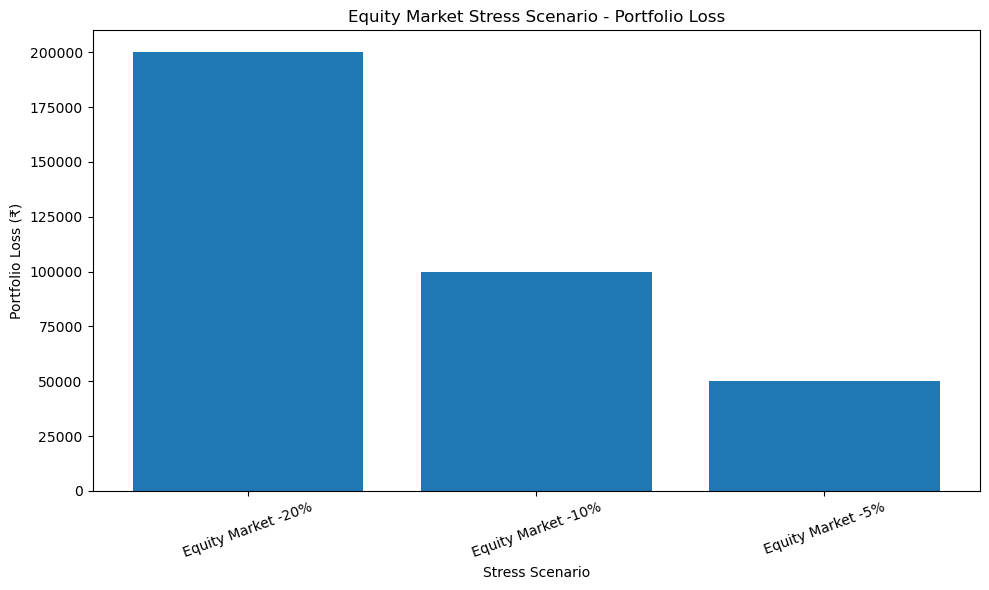

In [188]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    stress_results_df["Scenario"],
    stress_results_df["Stressed Loss"]
)

plt.title("Equity Market Stress Scenario - Portfolio Loss")
plt.xlabel("Stress Scenario")
plt.ylabel("Portfolio Loss (₹)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [189]:
# ============================================================
# STRESS SCENARIO 2: VOLATILITY DOUBLES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Current portfolio volatility
# ------------------------------------------------------------

current_volatility = portfolio_returns.std()

# Stress scenario: volatility doubles
stressed_volatility = current_volatility * 2

volatility_multiplier = stressed_volatility / current_volatility

print("----- Volatility Stress Test -----")
print(f"Current volatility:   {current_volatility:.6f}")
print(f"Stressed volatility:  {stressed_volatility:.6f}")
print(f"Volatility multiplier: {volatility_multiplier:.2f}x")

----- Volatility Stress Test -----
Current volatility:   0.011496
Stressed volatility:  0.022993
Volatility multiplier: 2.00x


In [190]:
# ============================================================
# CURRENT HISTORICAL VaR & EXPECTED SHORTFALL
# ============================================================

confidence_level = 0.99

# Convert returns into losses
losses = -portfolio_returns

# Historical VaR
historical_var = losses.quantile(confidence_level)

# Expected Shortfall
historical_es = losses[losses >= historical_var].mean()

print("----- Current Risk Measures -----")
print(f"Historical VaR (99%): {historical_var:.6f}")
print(f"Expected Shortfall:   {historical_es:.6f}")

----- Current Risk Measures -----
Historical VaR (99%): 0.032811
Expected Shortfall:   0.050209


## Now stress them using the 2× volatility assumption:

In [191]:
# ============================================================
# VOLATILITY ×2 STRESSED RISK MEASURES
# ============================================================

stressed_var_vol2 = historical_var * 2
stressed_es_vol2 = historical_es * 2

print("\n----- Volatility ×2 Stress Results -----")
print(f"Current VaR (99%):        {historical_var:.6f}")
print(f"Stressed VaR (99%):       {stressed_var_vol2:.6f}")

print(f"\nCurrent Expected Shortfall:  {historical_es:.6f}")
print(f"Stressed Expected Shortfall: {stressed_es_vol2:.6f}")


----- Volatility ×2 Stress Results -----
Current VaR (99%):        0.032811
Stressed VaR (99%):       0.065622

Current Expected Shortfall:  0.050209
Stressed Expected Shortfall: 0.100418


In [192]:
# ============================================================
# MONETARY STRESS LOSS
# ============================================================

current_var_loss = historical_var * portfolio_value
stressed_var_loss = stressed_var_vol2 * portfolio_value

current_es_loss = historical_es * portfolio_value
stressed_es_loss = stressed_es_vol2 * portfolio_value

print("----- Monetary Risk Measures -----")

print(f"Current VaR Loss:       ₹{current_var_loss:,.2f}")
print(f"Stressed VaR Loss:      ₹{stressed_var_loss:,.2f}")

print(f"Current ES Loss:        ₹{current_es_loss:,.2f}")
print(f"Stressed ES Loss:       ₹{stressed_es_loss:,.2f}")

----- Monetary Risk Measures -----
Current VaR Loss:       ₹32,811.22
Stressed VaR Loss:      ₹65,622.44
Current ES Loss:        ₹50,208.87
Stressed ES Loss:       ₹100,417.74


## Create a comparison table

In [193]:
# ============================================================
# VOLATILITY STRESS RESULT TABLE
# ============================================================

volatility_stress_result = pd.DataFrame({
    "Scenario": [
        "Current Conditions",
        "Volatility Doubles"
    ],
    
    "Volatility Multiplier": [
        1.0,
        2.0
    ],
    
    "VaR 99%": [
        historical_var,
        stressed_var_vol2
    ],
    
    "Expected Shortfall": [
        historical_es,
        stressed_es_vol2
    ],
    
    "VaR Loss (₹)": [
        current_var_loss,
        stressed_var_loss
    ],
    
    "ES Loss (₹)": [
        current_es_loss,
        stressed_es_loss
    ]
})

volatility_stress_result

,Scenario,Volatility Multiplier,VaR 99%,Expected Shortfall,VaR Loss (₹),ES Loss (₹)
0,Current Conditions,1.0,0.032811,0.050209,32811.220392,50208.869466
1,Volatility Doubles,2.0,0.065622,0.100418,65622.440783,100417.738932


## Plot the stress impact

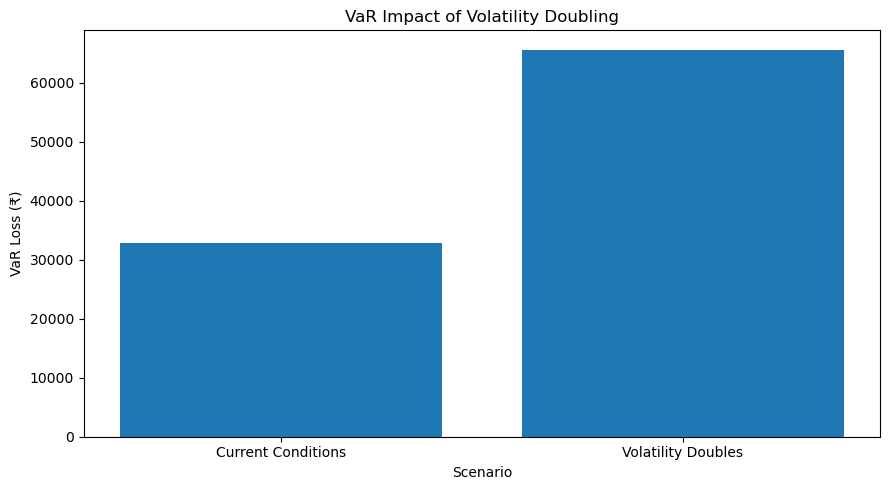

In [194]:
# ============================================================
# VOLATILITY STRESS VaR COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    volatility_stress_result["Scenario"],
    volatility_stress_result["VaR Loss (₹)"]
)

plt.title("VaR Impact of Volatility Doubling")
plt.ylabel("VaR Loss (₹)")
plt.xlabel("Scenario")

plt.tight_layout()
plt.show()

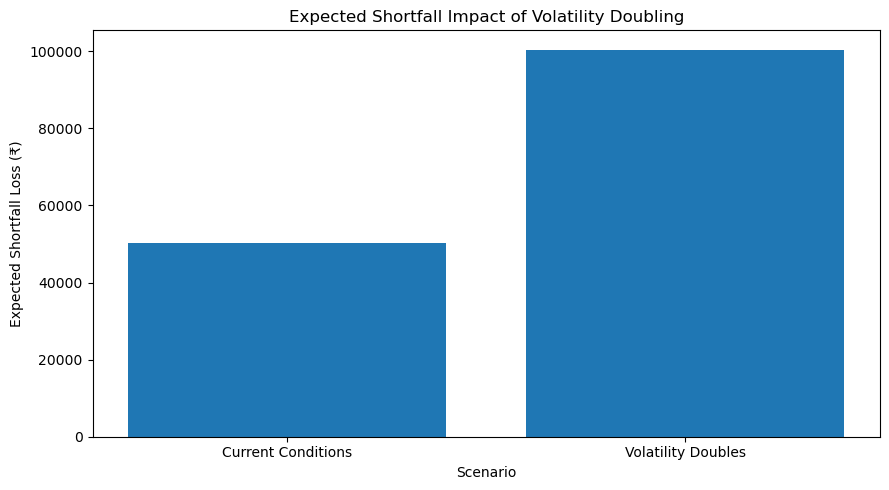

In [195]:
# ============================================================
# VOLATILITY STRESS ES COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    volatility_stress_result["Scenario"],
    volatility_stress_result["ES Loss (₹)"]
)

plt.title("Expected Shortfall Impact of Volatility Doubling")
plt.ylabel("Expected Shortfall Loss (₹)")
plt.xlabel("Scenario")

plt.tight_layout()
plt.show()

## Scenario 5: Correlation Spike

In [196]:
# ============================================================
# INDIVIDUAL STOCK RETURNS
# ============================================================

stock_returns = stock_prices.pct_change().dropna()

print("Stock returns shape:", stock_returns.shape)
stock_returns.head()

Stock returns shape: (2707, 50)


Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-05,-0.025059,-0.004166,-0.007220,0.019751,-0.005024,-0.033455,0.004057,0.000000,-0.027847,0.002582,...,0.006885,0.003190,0.021002,0.004043,0.032606,0.000090,0.001889,0.009912,-0.000378,0.008521
2016-01-06,-0.019570,0.000174,-0.087273,-0.003549,-0.001799,-0.030759,-0.015879,-0.021303,-0.011547,-0.011379,...,0.000302,-0.009667,-0.005377,-0.028931,-0.004227,-0.019648,-0.010199,-0.014199,-0.019096,-0.008321
2016-01-07,-0.042205,-0.002963,-0.091633,-0.024934,-0.039058,-0.031810,-0.041922,-0.036069,-0.024668,-0.043706,...,-0.019200,-0.008733,-0.026087,-0.027417,0.011485,-0.015477,-0.029440,-0.019276,-0.028528,-0.016006
2016-01-08,0.005288,-0.027268,-0.061403,-0.016491,-0.001464,-0.006587,-0.022705,-0.019355,-0.025900,-0.025180,...,-0.003690,-0.015678,-0.008928,0.000828,-0.015552,-0.021563,-0.017218,-0.013067,-0.016666,-0.020202
2016-01-11,0.016192,-0.031806,0.093458,0.002653,0.017610,-0.001248,0.001692,0.007237,-0.000598,0.001755,...,0.002366,0.009214,-0.001218,0.000827,-0.005015,-0.014929,-0.005265,0.002954,0.010694,-0.013389


## Calculate the current correlation matrix

In [197]:
# ============================================================
# CURRENT CORRELATION MATRIX
# ============================================================

correlation_matrix = stock_returns.corr()

print("Correlation matrix shape:")
print(correlation_matrix.shape)

Correlation matrix shape:
(50, 50)


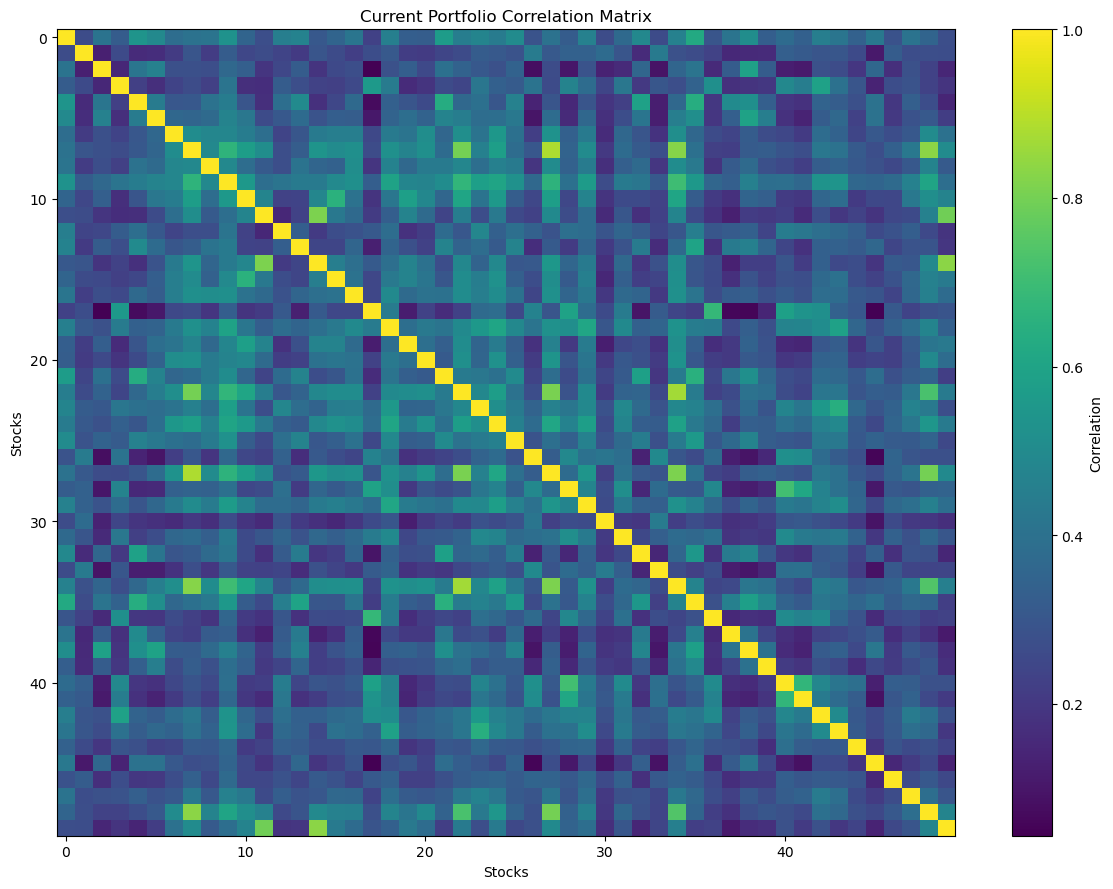

In [198]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

plt.imshow(correlation_matrix, aspect='auto')
plt.colorbar(label='Correlation')

plt.title("Current Portfolio Correlation Matrix")
plt.xlabel("Stocks")
plt.ylabel("Stocks")

plt.tight_layout()
plt.show()

### Step 1 — Create the stressed correlation matrix

In [199]:
# ============================================================
# PHASE 10: CORRELATION SPIKE STRESS SCENARIO
# ============================================================

import numpy as np
import pandas as pd

# Strength of the stress:
# 0.10 = mild, 0.25 = moderate, 0.50 = severe
correlation_stress_strength = 0.25

# Matrix where every stock has correlation 1 with every stock
high_correlation_matrix = np.ones_like(
    correlation_matrix.values,
    dtype=float
)

# Blend the original correlation matrix toward perfect correlation
stressed_correlation_values = (
    (1 - correlation_stress_strength)
    * correlation_matrix.values
    + correlation_stress_strength
    * high_correlation_matrix
)

stressed_correlation_matrix = pd.DataFrame(
    stressed_correlation_values,
    index=correlation_matrix.index,
    columns=correlation_matrix.columns
)

print("Correlation stress strength:",
      correlation_stress_strength)

print("\nOriginal average pairwise correlation:",
      correlation_matrix.where(
          ~np.eye(len(correlation_matrix), dtype=bool)
      ).stack().mean())

print("\nStressed average pairwise correlation:",
      stressed_correlation_matrix.where(
          ~np.eye(len(stressed_correlation_matrix), dtype=bool)
      ).stack().mean())

Correlation stress strength: 0.25

Original average pairwise correlation: 0.34165231658653217

Stressed average pairwise correlation: 0.5062392374398992


### Step 2 — Validate the stressed matrix

In [200]:
# ============================================================
# VALIDATE STRESSED CORRELATION MATRIX
# ============================================================

eigenvalues = np.linalg.eigvalsh(
    stressed_correlation_matrix.values
)

print("Minimum eigenvalue:", eigenvalues.min())
print("Matrix symmetric:",
      np.allclose(
          stressed_correlation_matrix.values,
          stressed_correlation_matrix.values.T
      ))

if eigenvalues.min() >= -1e-8:
    print("PASS: Stressed matrix is positive semi-definite.")
else:
    print("WARNING: Stressed matrix requires further repair.")

Minimum eigenvalue: 0.07799949541112232
Matrix symmetric: True
PASS: Stressed matrix is positive semi-definite.


### Step 3 — Build current and stressed covariance matrices

In [201]:
# ============================================================
# CURRENT AND STRESSED COVARIANCE MATRICES
# ============================================================

# Daily stock volatility
stock_volatility = stock_returns.std()

# Ensure consistent ticker ordering
stock_volatility = stock_volatility.reindex(
    correlation_matrix.columns
)

D = np.diag(stock_volatility.values)

# Current covariance matrix
current_covariance = (
    D @ correlation_matrix.values @ D
)

# Stressed covariance matrix
stressed_covariance = (
    D @ stressed_correlation_matrix.values @ D
)

print("Current covariance shape:",
      current_covariance.shape)

print("Stressed covariance shape:",
      stressed_covariance.shape)

Current covariance shape: (50, 50)
Stressed covariance shape: (50, 50)


### Step 4 — Calculate portfolio volatility under both scenarios

In [203]:
# ============================================================
# DIAGNOSE WEIGHT AND TICKER MISMATCH
# ============================================================

print("Type of weights:", type(weights))
print("Number of weights:", len(weights))
print("Number of return columns:", len(stock_returns.columns))

print("\nFirst 10 return column names:")
print(stock_returns.columns[:10].tolist())

print("\nWeights:")
print(weights)

print("\nWeight sum:", np.sum(weights))

Type of weights: <class 'numpy.ndarray'>
Number of weights: 50
Number of return columns: 50

First 10 return column names:
['AAPL', 'ABBV', 'AMD', 'AMT', 'AMZN', 'AVGO', 'BA', 'BAC', 'BKNG', 'BLK']

Weights:
[0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02
 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02
 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02
 0.02 0.02 0.02 0.02 0.02 0.02 0.02 0.02]

Weight sum: 1.0


In [204]:
# ============================================================
# FIX: ALIGN WEIGHTS WITH STOCK TICKERS
# ============================================================

# Ensure weights are a NumPy array
weights_array = np.asarray(weights, dtype=float).flatten()

# Validate number of weights against the number of stocks
if len(weights_array) != len(stock_returns.columns):
    raise ValueError(
        f"Mismatch: {len(weights_array)} weights for "
        f"{len(stock_returns.columns)} stocks."
    )

# Associate each weight with its stock ticker
weights_series = pd.Series(
    weights_array,
    index=stock_returns.columns,
    name="Weight"
)

# Validate weights
if weights_series.isna().any():
    raise ValueError("Missing weights detected.")

if not np.isclose(weights_series.sum(), 1.0):
    raise ValueError(
        f"Weights must sum to 1. Current sum: "
        f"{weights_series.sum():.6f}"
    )

print("Weight alignment successful!")
print("Number of stocks:", len(weights_series))
print("Total portfolio weight:", weights_series.sum())

display(weights_series.head(10))

Weight alignment successful!
Number of stocks: 50
Total portfolio weight: 1.0


Ticker
AAPL    0.02
ABBV    0.02
AMD     0.02
AMT     0.02
AMZN    0.02
AVGO    0.02
BA      0.02
BAC     0.02
BKNG    0.02
BLK     0.02
Name: Weight, dtype: float64

In [205]:
# Portfolio weights in the same order as the covariance matrix
w = weights_series.reindex(
    correlation_matrix.columns
).values

# Current and stressed portfolio volatility
current_portfolio_volatility = np.sqrt(
    w @ current_covariance @ w
)

stressed_portfolio_volatility = np.sqrt(
    w @ stressed_covariance @ w
)

print(f"Current daily volatility: "
      f"{current_portfolio_volatility:.6%}")

print(f"Stressed daily volatility: "
      f"{stressed_portfolio_volatility:.6%}")

print(f"Volatility multiplier: "
      f"{stressed_portfolio_volatility / current_portfolio_volatility:.3f}x")

Current daily volatility: 1.145987%
Stressed daily volatility: 1.386164%
Volatility multiplier: 1.210x


### Sector-Specific Shock

In [207]:
# ============================================================
# PHASE 10: SECTOR-SPECIFIC STRESS TEST
# STEP 1: IDENTIFY PORTFOLIO STOCKS
# ============================================================

print("Number of stocks:", len(stock_returns.columns))
print("\nPortfolio tickers:")

print(stock_returns.columns.tolist())

Number of stocks: 50

Portfolio tickers:
['AAPL', 'ABBV', 'AMD', 'AMT', 'AMZN', 'AVGO', 'BA', 'BAC', 'BKNG', 'BLK', 'CAT', 'COP', 'COST', 'CRM', 'CVX', 'DE', 'DIS', 'DUK', 'ECL', 'FCX', 'GE', 'GOOGL', 'GS', 'HD', 'HON', 'ISRG', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'MCD', 'META', 'MRK', 'MS', 'MSFT', 'NEE', 'NFLX', 'NVDA', 'ORCL', 'PEP', 'PG', 'PLD', 'SHW', 'TMUS', 'TSLA', 'UNH', 'UPS', 'WFC', 'XOM']


### Create a sector mapping

In [208]:
# ============================================================
# STEP 2: MAP STOCKS TO SECTORS
# ============================================================

sector_map = {
    # "AAPL": "Technology",
    # "MSFT": "Technology",
    # "JPM": "Financials",
    # Add your actual tickers and sectors here
}

missing_tickers = [
    ticker
    for ticker in stock_returns.columns
    if ticker not in sector_map
]

print("Unmapped tickers:", missing_tickers)

Unmapped tickers: ['AAPL', 'ABBV', 'AMD', 'AMT', 'AMZN', 'AVGO', 'BA', 'BAC', 'BKNG', 'BLK', 'CAT', 'COP', 'COST', 'CRM', 'CVX', 'DE', 'DIS', 'DUK', 'ECL', 'FCX', 'GE', 'GOOGL', 'GS', 'HD', 'HON', 'ISRG', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'MCD', 'META', 'MRK', 'MS', 'MSFT', 'NEE', 'NFLX', 'NVDA', 'ORCL', 'PEP', 'PG', 'PLD', 'SHW', 'TMUS', 'TSLA', 'UNH', 'UPS', 'WFC', 'XOM']


### Map all 50 stocks to sectors

In [209]:
# ============================================================
# PHASE 10: SECTOR-SPECIFIC STRESS TEST
# STEP 1: SECTOR MAPPING
# ============================================================

sector_map = {
    # Information Technology
    "AAPL": "Information Technology",
    "AMD": "Information Technology",
    "AVGO": "Information Technology",
    "CRM": "Information Technology",
    "MSFT": "Information Technology",
    "NVDA": "Information Technology",
    "ORCL": "Information Technology",

    # Communication Services
    "GOOGL": "Communication Services",
    "META": "Communication Services",
    "NFLX": "Communication Services",
    "TMUS": "Communication Services",
    "DIS": "Communication Services",

    # Consumer Discretionary
    "AMZN": "Consumer Discretionary",
    "BKNG": "Consumer Discretionary",
    "HD": "Consumer Discretionary",
    "MCD": "Consumer Discretionary",
    "TSLA": "Consumer Discretionary",

    # Consumer Staples
    "COST": "Consumer Staples",
    "KO": "Consumer Staples",
    "PEP": "Consumer Staples",
    "PG": "Consumer Staples",

    # Financials
    "BAC": "Financials",
    "BLK": "Financials",
    "GS": "Financials",
    "JPM": "Financials",
    "MS": "Financials",
    "WFC": "Financials",

    # Health Care
    "ABBV": "Health Care",
    "ISRG": "Health Care",
    "JNJ": "Health Care",
    "LLY": "Health Care",
    "MRK": "Health Care",
    "UNH": "Health Care",

    # Industrials
    "BA": "Industrials",
    "CAT": "Industrials",
    "DE": "Industrials",
    "GE": "Industrials",
    "HON": "Industrials",
    "UPS": "Industrials",

    # Energy
    "COP": "Energy",
    "CVX": "Energy",
    "XOM": "Energy",

    # Materials
    "ECL": "Materials",
    "FCX": "Materials",
    "LIN": "Materials",
    "SHW": "Materials",

    # Utilities
    "DUK": "Utilities",
    "NEE": "Utilities",

    # Real Estate
    "AMT": "Real Estate",
    "PLD": "Real Estate",
}

# Check mapping completeness
missing_tickers = [
    ticker for ticker in stock_returns.columns
    if ticker not in sector_map
]

extra_tickers = [
    ticker for ticker in sector_map
    if ticker not in stock_returns.columns
]

print("Portfolio stocks:", len(stock_returns.columns))
print("Mapped stocks:", sum(
    ticker in sector_map for ticker in stock_returns.columns
))
print("Missing tickers:", missing_tickers)
print("Unexpected tickers:", extra_tickers)

assert not missing_tickers, "Map every portfolio ticker before proceeding."

Portfolio stocks: 50
Mapped stocks: 50
Missing tickers: []
Unexpected tickers: []


In [210]:
# ============================================================
# STEP 2: SECTOR EXPOSURE
# ============================================================

sector_exposure = pd.DataFrame({
    "Ticker": weights_series.index,
    "Weight": weights_series.values,
})

sector_exposure["Sector"] = (
    sector_exposure["Ticker"].map(sector_map)
)

sector_summary = (
    sector_exposure
    .groupby("Sector")["Weight"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sector_summary["Weight (%)"] = (
    sector_summary["Weight"] * 100
)

display(sector_summary.round(2))

,Sector,Weight,Weight (%)
0,Communication Services,0.0,0.0
1,Consumer Discretionary,0.0,0.0
2,Consumer Staples,0.0,0.0
3,Energy,0.0,0.0
4,Financials,0.0,0.0
5,Health Care,0.0,0.0
6,Industrials,0.0,0.0
7,Information Technology,0.0,0.0
8,Materials,0.0,0.0
9,Real Estate,0.0,0.0


In [212]:
print("Stock returns columns:")
print(stock_returns.columns.tolist())

print("\nWeights series:")
print(weights_series)

print("\nWeights sum:")
print(weights_series.sum())

print("\nWeights data type:")
print(weights_series.dtype)

Stock returns columns:
['AAPL', 'ABBV', 'AMD', 'AMT', 'AMZN', 'AVGO', 'BA', 'BAC', 'BKNG', 'BLK', 'CAT', 'COP', 'COST', 'CRM', 'CVX', 'DE', 'DIS', 'DUK', 'ECL', 'FCX', 'GE', 'GOOGL', 'GS', 'HD', 'HON', 'ISRG', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'MCD', 'META', 'MRK', 'MS', 'MSFT', 'NEE', 'NFLX', 'NVDA', 'ORCL', 'PEP', 'PG', 'PLD', 'SHW', 'TMUS', 'TSLA', 'UNH', 'UPS', 'WFC', 'XOM']

Weights series:
Ticker
AAPL    NaN
ABBV    NaN
AMD     NaN
AMT     NaN
AMZN    NaN
AVGO    NaN
BA      NaN
BAC     NaN
BKNG    NaN
BLK     NaN
CAT     NaN
COP     NaN
COST    NaN
CRM     NaN
CVX     NaN
DE      NaN
DIS     NaN
DUK     NaN
ECL     NaN
FCX     NaN
GE      NaN
GOOGL   NaN
GS      NaN
HD      NaN
HON     NaN
ISRG    NaN
JNJ     NaN
JPM     NaN
KO      NaN
LIN     NaN
LLY     NaN
MCD     NaN
META    NaN
MRK     NaN
MS      NaN
MSFT    NaN
NEE     NaN
NFLX    NaN
NVDA    NaN
ORCL    NaN
PEP     NaN
PG      NaN
PLD     NaN
SHW     NaN
TMUS    NaN
TSLA    NaN
UNH     NaN
UPS     NaN
WFC     NaN
XOM   

In [213]:
import numpy as np
import pandas as pd

tickers = stock_returns.columns

weights_series = pd.Series(
    np.ones(len(tickers)) / len(tickers),
    index=tickers,
    name="Weight"
)

print(weights_series.head())
print("Total weight:", weights_series.sum())

Ticker
AAPL    0.02
ABBV    0.02
AMD     0.02
AMT     0.02
AMZN    0.02
Name: Weight, dtype: float64
Total weight: 1.0


In [214]:
sector_exposure = pd.DataFrame({
    "Ticker": weights_series.index,
    "Weight": weights_series.values
})

sector_exposure["Sector"] = sector_exposure["Ticker"].map(sector_map)

sector_summary = (
    sector_exposure.groupby("Sector", as_index=False)["Weight"]
    .sum()
    .sort_values("Weight", ascending=False)
)

sector_summary["Weight (%)"] = sector_summary["Weight"] * 100

display(sector_summary.round(4))

,Sector,Weight,Weight (%)
7,Information Technology,0.14,14.0
4,Financials,0.12,12.0
5,Health Care,0.12,12.0
6,Industrials,0.12,12.0
0,Communication Services,0.10,10.0
1,Consumer Discretionary,0.10,10.0
2,Consumer Staples,0.08,8.0
8,Materials,0.08,8.0
3,Energy,0.06,6.0
9,Real Estate,0.04,4.0


### Apply a −15% Technology shock

In [215]:
# ============================================================
# STEP 3: SECTOR-SPECIFIC SHOCK
# ============================================================

sector_to_stress = "Information Technology"
sector_return_shock = -0.15

# Portfolio value should be the existing value in your notebook.
# Do not overwrite it if already defined.

tech_tickers = [
    ticker for ticker in stock_returns.columns
    if sector_map[ticker] == sector_to_stress
]

tech_weight = weights_series.reindex(
    tech_tickers
).sum()

# Portfolio-level return contribution from the sector shock
portfolio_return_impact = (
    tech_weight * sector_return_shock
)

stressed_portfolio_loss = (
    -portfolio_return_impact * portfolio_value
)

stressed_portfolio_value = (
    portfolio_value - stressed_portfolio_loss
)

print("Sector:", sector_to_stress)
print("Number of affected stocks:", len(tech_tickers))
print(f"Sector portfolio weight: {tech_weight:.2%}")
print(f"Sector shock: {sector_return_shock:.2%}")
print(f"Portfolio return impact: {portfolio_return_impact:.2%}")
print(f"Stressed portfolio loss: ₹{stressed_portfolio_loss:,.2f}")
print(f"Stressed portfolio value: ₹{stressed_portfolio_value:,.2f}")

Sector: Information Technology
Number of affected stocks: 7
Sector portfolio weight: 14.00%
Sector shock: -15.00%
Portfolio return impact: -2.10%
Stressed portfolio loss: ₹21,000.00
Stressed portfolio value: ₹979,000.00


### Compare shocks across every sector

In [216]:
# ============================================================
# STEP 4: SECTOR SHOCK COMPARISON
# ============================================================

sector_results = []

for sector in sorted(set(sector_map.values())):

    affected_tickers = [
        ticker for ticker in stock_returns.columns
        if sector_map[ticker] == sector
    ]

    sector_weight = weights_series.reindex(
        affected_tickers
    ).sum()

    portfolio_return_impact = (
        sector_weight * sector_return_shock
    )

    loss = -portfolio_return_impact * portfolio_value

    sector_results.append({
        "Sector": sector,
        "Stocks": len(affected_tickers),
        "Sector Weight (%)": sector_weight * 100,
        "Shock (%)": sector_return_shock * 100,
        "Portfolio Impact (%)": portfolio_return_impact * 100,
        "Stressed Loss (₹)": loss,
    })

sector_stress_results = (
    pd.DataFrame(sector_results)
    .sort_values("Stressed Loss (₹)", ascending=False)
    .reset_index(drop=True)
)

display(sector_stress_results.round(2))

,Sector,Stocks,Sector Weight (%),Shock (%),Portfolio Impact (%),Stressed Loss (₹)
0,Information Technology,7,14.0,-15.0,-2.1,21000.0
1,Financials,6,12.0,-15.0,-1.8,18000.0
2,Health Care,6,12.0,-15.0,-1.8,18000.0
3,Industrials,6,12.0,-15.0,-1.8,18000.0
4,Communication Services,5,10.0,-15.0,-1.5,15000.0
5,Consumer Discretionary,5,10.0,-15.0,-1.5,15000.0
6,Consumer Staples,4,8.0,-15.0,-1.2,12000.0
7,Materials,4,8.0,-15.0,-1.2,12000.0
8,Energy,3,6.0,-15.0,-0.9,9000.0
9,Real Estate,2,4.0,-15.0,-0.6,6000.0


### Plot sector impact

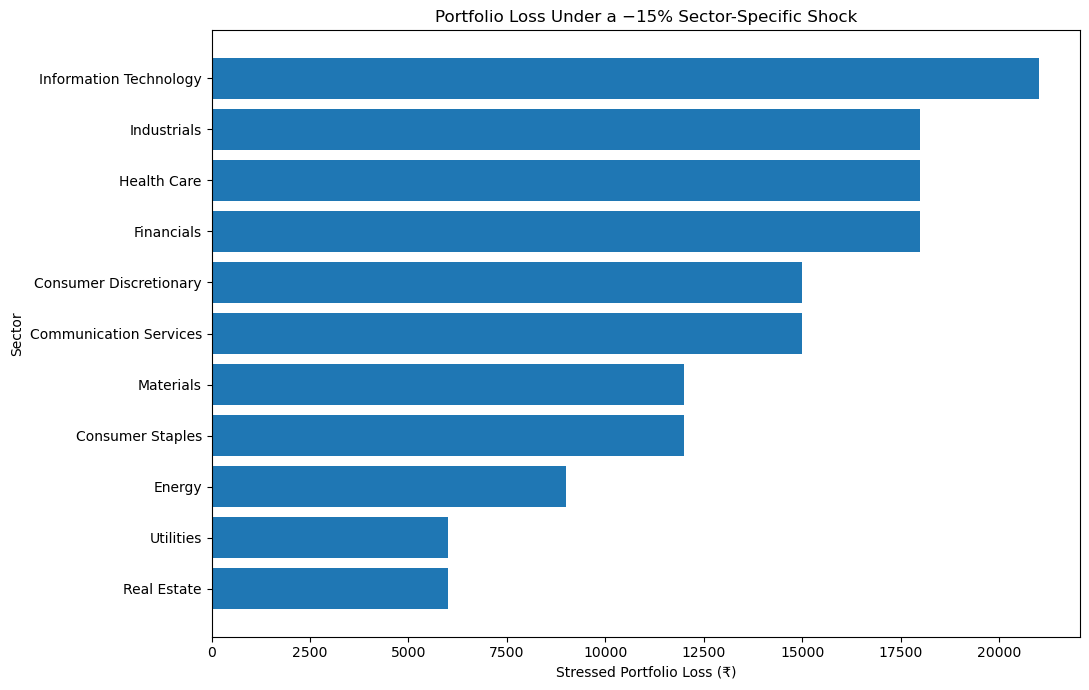

In [217]:
# ============================================================
# STEP 5: SECTOR SHOCK IMPACT CHART
# ============================================================

import matplotlib.pyplot as plt

plot_data = sector_stress_results.sort_values(
    "Stressed Loss (₹)",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_data["Sector"],
    plot_data["Stressed Loss (₹)"]
)

plt.title("Portfolio Loss Under a −15% Sector-Specific Shock")
plt.xlabel("Stressed Portfolio Loss (₹)")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()